# ML4SCI DeepFalcon GSoC 2026 — Quark/Gluon Jet Generation & Classification (5000 Sampled)

## Tasks Covered
| Task | Description |
|------|-------------|
| Common Task 1 | Variational Autoencoder (Basic VAE + Physics-Informed VAE) |
| Common Task 2 | Graph Neural Network Jet Classification |
| Specific Task 2 | Denoising Diffusion Probabilistic Models (Basic DDPM + Physics-Informed DDPM) |

---

## Physics Background

Proton–proton collisions at the Large Hadron Collider (LHC) produce collimated
sprays of particles called **jets**. A jet originates from a high-energy quark or
gluon — collectively called *partons* — produced in a hard-scattering event.
Discriminating quark-initiated jets from gluon-initiated jets (*quark/gluon tagging*)
is a key task in high-energy physics (HEP) with applications in Higgs-boson
measurements, searches for physics beyond the Standard Model, and precision QCD
studies [1].

Quarks and gluons carry different **color charges** under Quantum Chromodynamics
(QCD), which governs how strongly particles radiate:
- **Quarks**: colour factor $C_F = 4/3$ → narrower jets, lower multiplicity
- **Gluons**: colour factor $C_A = 3$ → broader jets, higher multiplicity [2]

### Detector Channels
| Channel | Physical Meaning |
|---------|-----------------|
| **ECAL** (Ch 0) | Electromagnetic Calorimeter — electrons & photons |
| **HCAL** (Ch 1) | Hadronic Calorimeter — charged & neutral hadrons |
| **Tracks** (Ch 2) | Silicon tracker — charged particles only |

Jet images are in the **(η, φ) plane** where η = pseudorapidity and φ = azimuthal
angle, both centred on the jet axis. A high dynamic range is expected — a few
*hot pixels* carry most of the energy [3].

### Physics-Informed Constraints Used in This Notebook
1. **Energy / pT conservation** — total pixel sum ∝ jet pT must be preserved
2. **Jet width (girth)** — pT-weighted mean ΔR from the jet axis; wider for gluons
3. **Charged multiplicity** — active pixels in the Tracks channel; higher for gluons
4. **Channel energy fractions** — ECAL/HCAL/Track energy ratios encode detector signatures

### References
[1] Andrews et al., *"End-to-end jet classification of quarks and gluons with the CMS Open Data"*, 2020  
[2] Gras et al., *"Systematics of quark/gluon tagging"*, JHEP 2017  
[3] Komiske et al., *"Energy Flow Networks: Deep Sets for Particle Jets"*, JHEP 2019  
[4] Qu & Gouskos, *"ParticleNet: Jet Tagging via Particle Clouds"*, PRD 2020  
[5] Ho et al., *"Denoising Diffusion Probabilistic Models"*, NeurIPS 2020  
[6] Kansal et al., *"Particle Cloud Generation with Message Passing GANs"*, NeurIPS 2021  

Due to hardware constraints only 5000 samples out of 130000 are used for quick training and less RAM

## 0. Environment Setup

In [1]:
!gdown --fuzzy https://drive.google.com/file/d/1WO2K-SfU2dntGU4Bb3IYBp9Rh7rtTYEr/view?usp=sharing

Downloading...
From (original): https://drive.google.com/uc?id=1WO2K-SfU2dntGU4Bb3IYBp9Rh7rtTYEr
From (redirected): https://drive.google.com/uc?id=1WO2K-SfU2dntGU4Bb3IYBp9Rh7rtTYEr&confirm=t&uuid=0bc4f4e3-1aeb-45fc-8c5d-e766a42df72c
To: /kaggle/working/quark-gluon_data-set_n139306.hdf5
100%|████████████████████████████████████████| 701M/701M [00:08<00:00, 83.0MB/s]


In [2]:
!pip uninstall -y torch torchvision torchaudio

!pip install torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0 \
  --index-url https://download.pytorch.org/whl/cu126 --quiet

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 183.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 235.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 189.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 65.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 82.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 121.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.

In [3]:
!pip install torch_geometric >/dev/null #torch-scatter torch-sparse

## 1. Imports & Global Configuration

In [33]:
import os, math, time, warnings
warnings.filterwarnings("ignore")

import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.transforms.functional import resize as tv_resize
import torchvision.transforms as T

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve
from scipy.stats import wasserstein_distance
from scipy.spatial.distance import jensenshannon

# PyTorch Geometric for the GNN
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import DynamicEdgeConv, global_max_pool, global_mean_pool

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ─── Global Hyperparameters ──────────────────────────────────────────────────
CFG = dict(
    # Data
    DATA_PATH   = "quark-gluon_data-set_n139306.hdf5",
    N_SAMPLES   = 5000,              # samples used (reduce if RAM is tight)
    IMG_SIZE    = 128,               # resize target (must be power-of-2; 125→128)
    DIFF_SIZE   = 32,                # resolution for diffusion model
    CHANNELS    = 3,                 # ECAL, HCAL, Tracks
    NUM_WORKERS = 4,

    # VAE
    VAE_LATENT  = 64,
    VAE_BETA    = 0.0,               # weight of KL term
    VAE_PHY_LAM = 0.005,               # weight of physics loss in PI-VAE
    VAE_EPOCHS  = 60,
    VAE_LR      = 1e-4,
    VAE_BATCH   = 32,

    # GNN
    GNN_K       = 12,                # k-NN neighbours in graph
    GNN_EPOCHS  = 120,
    GNN_LR      = 1e-5,
    GNN_BATCH   = 32,
    GNN_MAX_PTS = 150,               # max particles per jet (speed)

    # DDPM
    DIFF_T      = 500,               # diffusion timesteps
    DIFF_EPOCHS = 100,
    DIFF_LR     = 2e-4,
    DIFF_BATCH  = 64,

    # Eval
    N_VIS       = 6,                 # samples to visualise
    VAL_FRAC    = 0.15,
    TEST_FRAC   = 0.15,
)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                      "grid.alpha": 0.3, "font.size": 11})
print("Configuration ready.")

Using device: cuda
Configuration ready.


## 2. Data Loading & Preprocessing

### Preprocessing Pipeline
1. **Clip** extreme values at the 99th percentile per channel — jet images have a
   very high dynamic range and a handful of extremely bright pixels would dominate
   gradients [3].
2. **Normalise** to **[0, 1]** using the clipped maximum.
3. **Resize** from 125×125 → 128×128 so that four stride-2 convolutions land on
   integer dimensions (128 → 64 → 32 → 16 → 8).

In [34]:
class JetDataset(Dataset):
    """
    PyTorch Dataset for quark/gluon jet calorimeter images.

    Each item is a dict:
        'image' : FloatTensor (C, H, W) normalised to [0,1]
        'label' : int  (0=quark, 1=gluon)
        'm0'    : float  (jet mass proxy)
        'pt'    : float  (transverse momentum)
    """
    def __init__(self, images, labels, m0, pt, img_size=128):
        self.images = images      # (N, C, H, W) float32 pre-processed
        self.labels = labels.astype(np.int64)
        self.m0     = m0.astype(np.float32)
        self.pt     = pt.astype(np.float32)
        self.img_size = img_size

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx], dtype=torch.float32)   # (C,H,W)
        # Resize in-place if needed
        if img.shape[-1] != self.img_size:
            img = F.interpolate(img.unsqueeze(0), size=self.img_size,
                                mode='bilinear', align_corners=False).squeeze(0)
        return {
            'image': img,
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
            'm0'   : torch.tensor(self.m0[idx],    dtype=torch.float32),
            'pt'   : torch.tensor(self.pt[idx],    dtype=torch.float32),
        }


def preprocess_jet_images(raw, percentile=99.9):
    """
    Clip and normalise jet images.

    Args:
        raw: ndarray (N, H, W, C)  uint8 or float
    Returns:
        images_nchw: ndarray (N, C, H, W) float32 in [0,1]
        clip_vals:   per-channel 99th-percentile values used for clipping
    """
    raw = raw.astype(np.float32)
    N, H, W, C = raw.shape
    clip_vals = np.percentile(raw, percentile, axis=(0, 1, 2))  # (C,)
    clipped   = np.clip(raw, 0, clip_vals[None, None, None, :])
    # Normalise per channel
    maxv = clip_vals.copy()
    maxv[maxv == 0] = 1.0          # avoid division by zero
    normalised = clipped / maxv[None, None, None, :]
    # NHWC → NCHW
    return normalised.transpose(0, 3, 1, 2), clip_vals


def load_data(path, n_samples=20_000, img_size=128, seed=SEED):
    """Load and preprocess the HDF5 dataset, returning split DataLoaders."""
    print(f"Loading data from: {path}")
    with h5py.File(path, 'r') as f:
        total = f['X_jets'].shape[0]
        idx   = np.random.RandomState(seed).choice(total, n_samples, replace=False)
        idx   = np.sort(idx)
        raw   = f['X_jets'][idx]     # (N, 125, 125, 3)
        m0    = f['m0'][idx]
        pt    = f['pt'][idx]
        y     = f['y'][idx]

    print(f"  Loaded {n_samples} / {total} events")
    images_nchw, clip_vals = preprocess_jet_images(raw)
    print(f"  Channel 99th-pct clip values: ECAL={clip_vals[0]:.2f}  "
          f"HCAL={clip_vals[1]:.2f}  Tracks={clip_vals[2]:.2f}")

    # Splits: 70 / 15 / 15
    idx_all    = np.arange(n_samples)
    idx_tr, idx_tmp = train_test_split(idx_all, test_size=CFG['VAL_FRAC']+CFG['TEST_FRAC'],
                                       random_state=seed, stratify=y)
    idx_val, idx_te = train_test_split(idx_tmp, test_size=0.5,
                                       random_state=seed, stratify=y[idx_tmp])
    print(f"  Train={len(idx_tr)}  Val={len(idx_val)}  Test={len(idx_te)}")

    ds_tr  = JetDataset(images_nchw[idx_tr],  y[idx_tr],  m0[idx_tr],  pt[idx_tr],  img_size)
    ds_val = JetDataset(images_nchw[idx_val], y[idx_val], m0[idx_val], pt[idx_val], img_size)
    ds_te  = JetDataset(images_nchw[idx_te],  y[idx_te],  m0[idx_te],  pt[idx_te],  img_size)

    def make_loader(ds, batch, shuffle):
        return DataLoader(ds, batch_size=batch, shuffle=shuffle,
                          num_workers=2, pin_memory=True)

    return (ds_tr, ds_val, ds_te,
            make_loader(ds_tr,  CFG['VAE_BATCH'], True),
            make_loader(ds_val, CFG['VAE_BATCH'], False),
            make_loader(ds_te,  CFG['VAE_BATCH'], False))


# ── Synthetic demo data (used if the real HDF5 file is not present) ──────────
def make_synthetic_data(n=2000, h=125, w=125, c=3, seed=SEED):
    """Generate tiny random jet-like images for CI / notebook preview."""
    rng = np.random.RandomState(seed)
    raw = np.zeros((n, h, w, c), dtype=np.float32)
    y   = rng.randint(0, 2, size=n).astype(np.int64)
    # Quark jets: narrower Gaussian deposits
    # Gluon jets: broader + higher multiplicity
    for i in range(n):
        n_hits = 30 + 20 * y[i] + rng.randint(0, 20)
        for _ in range(n_hits):
            sigma = 8 + 6 * y[i]
            cx = rng.randint(30, 95); cy = rng.randint(30, 95)
            ex = np.clip(int(cx + rng.randn() * sigma), 0, h-1)
            ey = np.clip(int(cy + rng.randn() * sigma), 0, w-1)
            for ch in range(c):
                raw[i, ex, ey, ch] += rng.exponential(1.0)
    m0 = rng.uniform(5,  80,  n).astype(np.float32)
    pt = rng.uniform(100, 500, n).astype(np.float32)
    return raw, y, m0, pt


USE_SYNTHETIC = not Path(CFG['DATA_PATH']).exists()
if USE_SYNTHETIC:
    print(" Real HDF5 not found — using synthetic demo data (results are illustrative only).")
    raw_syn, y_syn, m0_syn, pt_syn = make_synthetic_data(CFG['N_SAMPLES'])
    images_syn, _  = preprocess_jet_images(raw_syn)
    idx_all        = np.arange(len(y_syn))
    idx_tr, idx_tmp = train_test_split(idx_all, test_size=0.30, random_state=SEED, stratify=y_syn)
    idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50, random_state=SEED, stratify=y_syn[idx_tmp])
    ds_tr  = JetDataset(images_syn[idx_tr],  y_syn[idx_tr],  m0_syn[idx_tr],  pt_syn[idx_tr])
    ds_val = JetDataset(images_syn[idx_val], y_syn[idx_val], m0_syn[idx_val], pt_syn[idx_val])
    ds_te  = JetDataset(images_syn[idx_te],  y_syn[idx_te],  m0_syn[idx_te],  pt_syn[idx_te])
    loader_tr  = DataLoader(ds_tr,  batch_size=CFG['VAE_BATCH'], shuffle=True,  num_workers=0)
    loader_val = DataLoader(ds_val, batch_size=CFG['VAE_BATCH'], shuffle=False, num_workers=0)
    loader_te  = DataLoader(ds_te,  batch_size=CFG['VAE_BATCH'], shuffle=False, num_workers=0)
else:
    ds_tr, ds_val, ds_te, loader_tr, loader_val, loader_te = load_data(
        CFG['DATA_PATH'], CFG['N_SAMPLES'], CFG['IMG_SIZE'])

print(f"\nDataset sizes — Train: {len(ds_tr)}  Val: {len(ds_val)}  Test: {len(ds_te)}")

Loading data from: quark-gluon_data-set_n139306.hdf5
  Loaded 5000 / 139306 events
  Channel 99th-pct clip values: ECAL=0.01  HCAL=0.01  Tracks=0.01
  Train=3500  Val=750  Test=750

Dataset sizes — Train: 3500  Val: 750  Test: 750


## 3. Exploratory Data Analysis

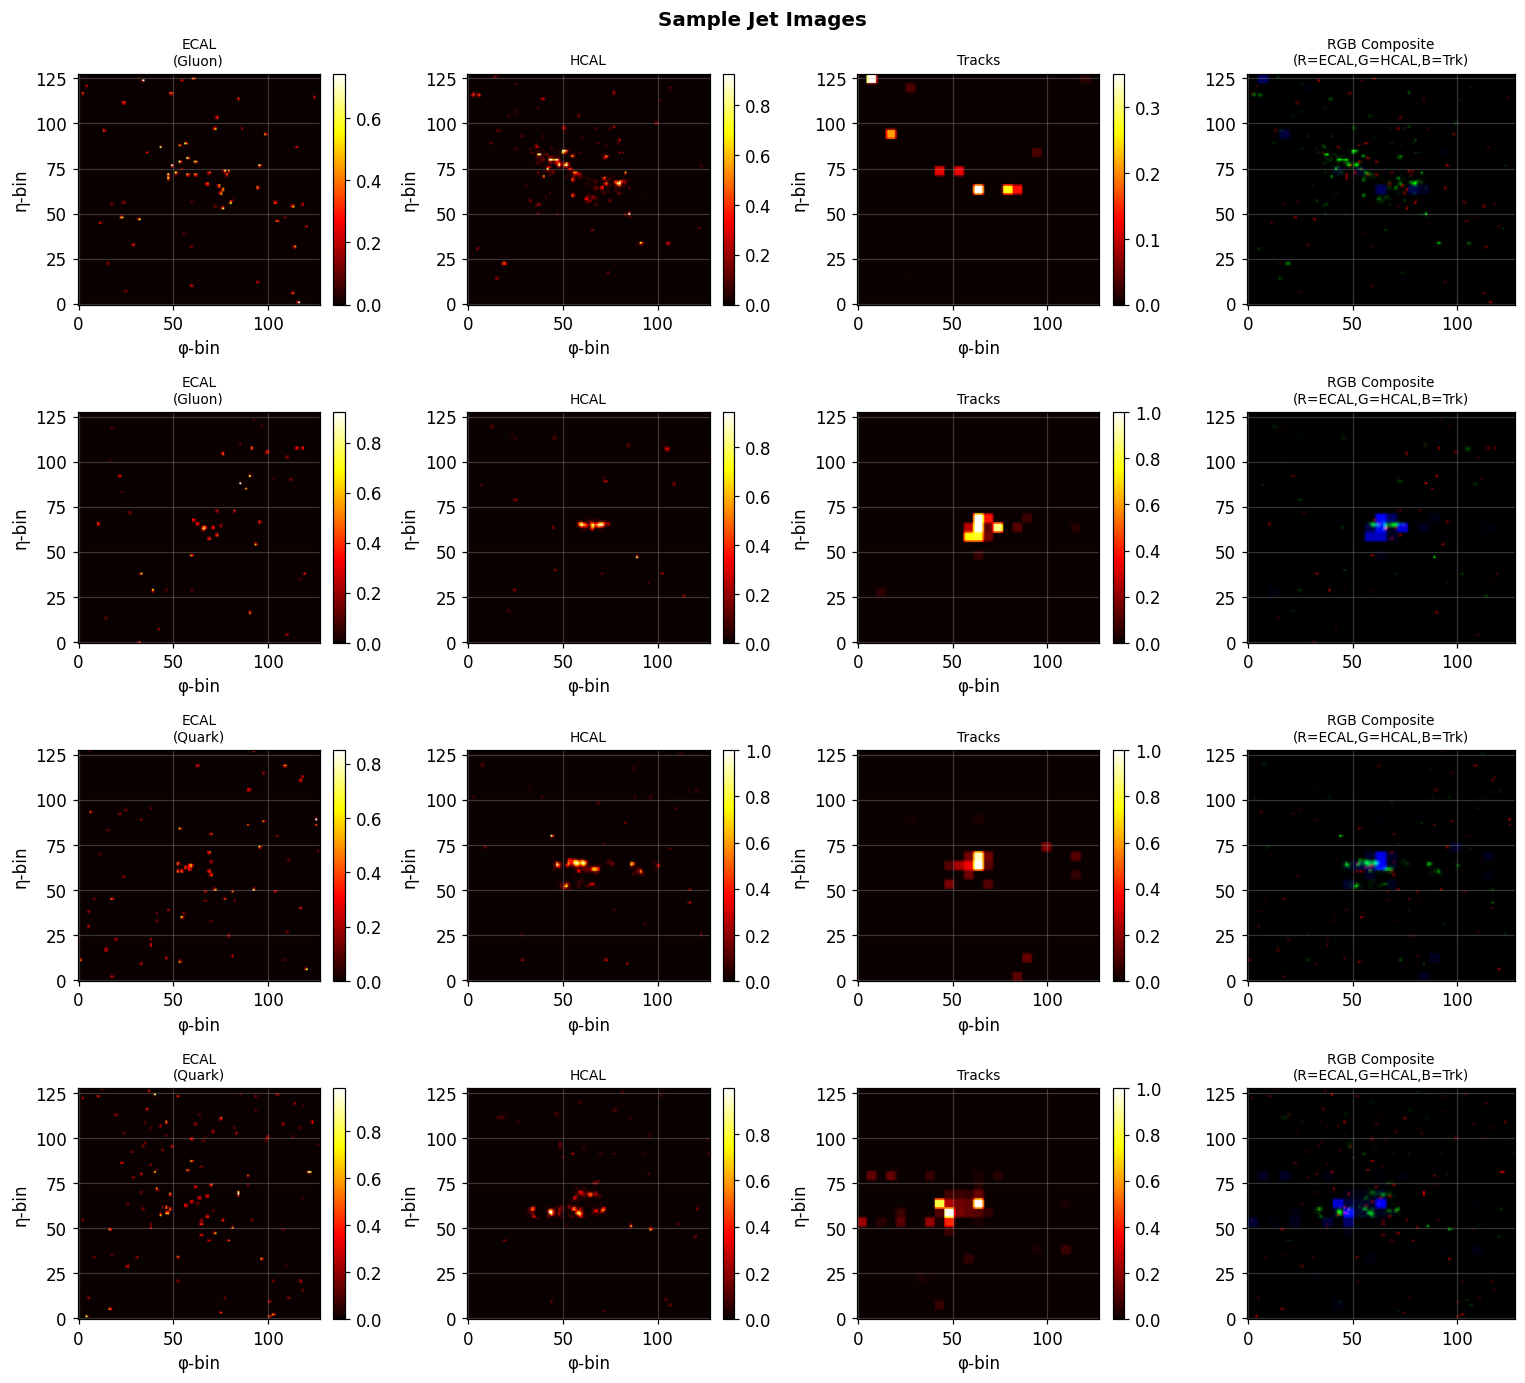

In [35]:
def show_sample_jets(dataset, n=4, title="Sample Jet Images"):
    """Display n jet images with ECAL / HCAL / Track channels + composite."""
    ch_names = ["ECAL", "HCAL", "Tracks"]
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.2 * n))
    for row in range(n):
        item   = dataset[row]
        img    = item['image'].numpy()          # (C, H, W)
        label  = "Gluon" if item['label'].item() else "Quark"
        for ch, name in enumerate(ch_names):
            ax = axes[row, ch]
            im = ax.imshow(img[ch], cmap='hot', origin='lower', aspect='auto')
            ax.set_title(f"{name}\n({label})" if ch == 0 else name, fontsize=9)
            plt.colorbar(im, ax=ax, fraction=0.046)
            ax.set_xlabel("φ-bin"); ax.set_ylabel("η-bin")
        # RGB composite
        composite = np.stack([img[0], img[1], img[2]], axis=-1)
        composite = composite / (composite.max() + 1e-8)
        axes[row, 3].imshow(composite, origin='lower', aspect='auto')
        axes[row, 3].set_title("RGB Composite\n(R=ECAL,G=HCAL,B=Trk)", fontsize=9)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


show_sample_jets(ds_tr, n=4)

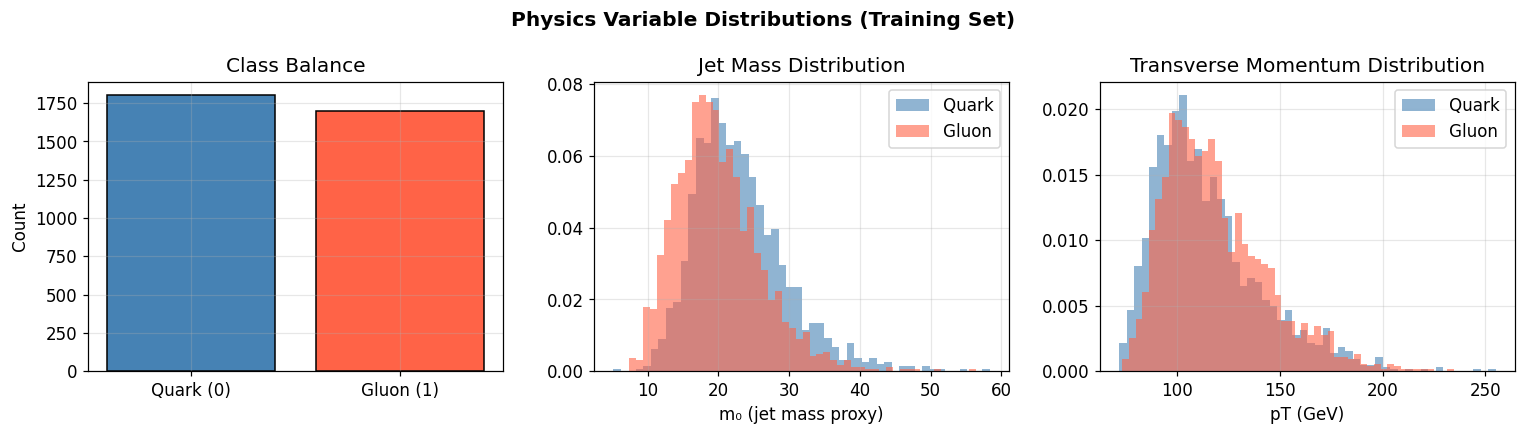

In [36]:
# ── Label and physics-variable distributions ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

all_labels = np.array([ds_tr[i]['label'].item() for i in range(len(ds_tr))])
all_m0     = np.array([ds_tr[i]['m0'].item()    for i in range(len(ds_tr))])
all_pt     = np.array([ds_tr[i]['pt'].item()    for i in range(len(ds_tr))])

# Label counts
axes[0].bar(["Quark (0)", "Gluon (1)"],
            [(all_labels == 0).sum(), (all_labels == 1).sum()],
            color=['steelblue', 'tomato'], edgecolor='k')
axes[0].set_title("Class Balance")
axes[0].set_ylabel("Count")

# Jet mass
for cls, col, lbl in zip([0, 1], ['steelblue', 'tomato'], ['Quark', 'Gluon']):
    axes[1].hist(all_m0[all_labels == cls], bins=50, density=True,
                 alpha=0.6, color=col, label=lbl)
axes[1].set_xlabel("m₀ (jet mass proxy)")
axes[1].set_title("Jet Mass Distribution")
axes[1].legend()

# Transverse momentum
for cls, col, lbl in zip([0, 1], ['steelblue', 'tomato'], ['Quark', 'Gluon']):
    axes[2].hist(all_pt[all_labels == cls], bins=50, density=True,
                 alpha=0.6, color=col, label=lbl)
axes[2].set_xlabel("pT (GeV)")
axes[2].set_title("Transverse Momentum Distribution")
axes[2].legend()

plt.suptitle("Physics Variable Distributions (Training Set)", fontweight='bold')
plt.tight_layout()
plt.show()

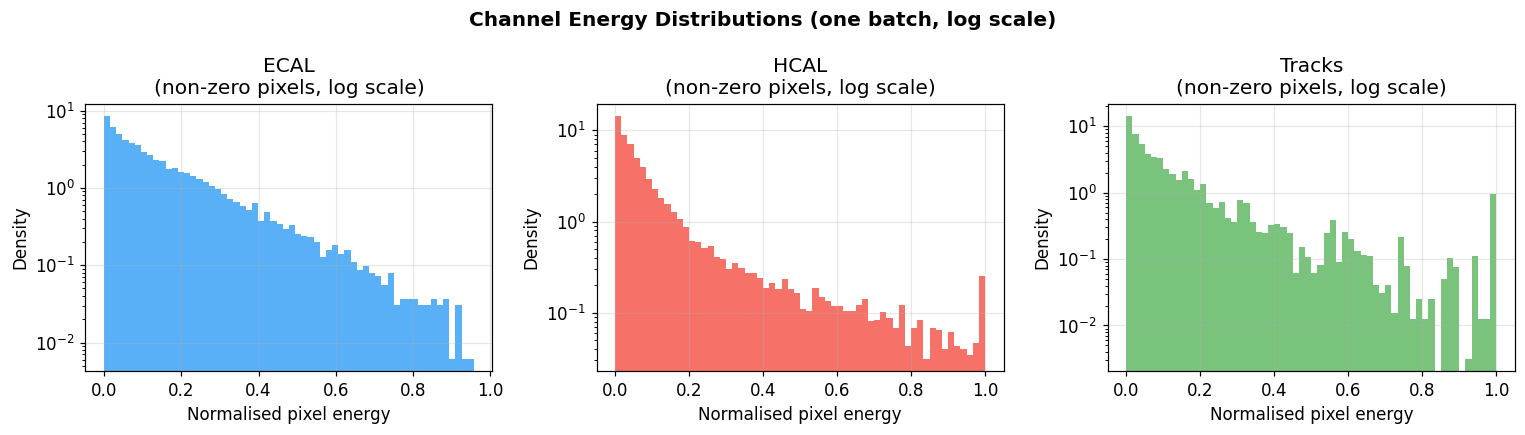

EDA complete.


In [37]:
# ── Per-channel energy statistics ─────────────────────────────────────────────
# Sample a batch for quick statistics
batch = next(iter(loader_tr))['image'].numpy()    # (B, 3, 128, 128)
ch_names = ["ECAL", "HCAL", "Tracks"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ch in range(3):
    flat = batch[:, ch].ravel()
    flat_nz = flat[flat > 1e-4]
    axes[ch].hist(flat_nz, bins=60, color=['#2196F3','#F44336','#4CAF50'][ch],
                  alpha=0.75, log=True, density=True)
    axes[ch].set_title(f"{ch_names[ch]}\n(non-zero pixels, log scale)")
    axes[ch].set_xlabel("Normalised pixel energy")
    axes[ch].set_ylabel("Density")
plt.suptitle("Channel Energy Distributions (one batch, log scale)", fontweight='bold')
plt.tight_layout()
plt.show()
print("EDA complete.")

## 4. Common Task 1 — Variational Autoencoder (VAE)

### Architecture
A Fully connrected encoder maps each 3×128×128 jet image through four layers to a linear layer, then two linear layers produce the mean **μ** and
log-variance **log σ²** of a Gaussian latent code z ∈ ℝ^256.  A mirror FCN
decoder reconstructs the image from z.

### Loss Function
$$\mathcal{L}_{\text{VAE}} = \underbrace{\|x - \hat{x}\|^2_2}_{\text{recon (MSE)}}
  + \beta \cdot \underbrace{D_{\text{KL}}(q(z|x)\,\|\,\mathcal{N}(0,I))}_{\text{KL divergence}}$$

β-VAE (β > 1) encourages a more disentangled latent space [Higgins et al. 2017].

### Physics-Informed Extension (PI-VAE)
An auxiliary **physics consistency loss** is added:
$$\mathcal{L}_{\text{PI-VAE}} = \mathcal{L}_{\text{VAE}}
  + \lambda_{\text{phys}}\,\mathcal{L}_{\text{phys}}(\hat{x}, x)$$
where $\mathcal{L}_{\text{phys}}$ penalises discrepancies in four IRC-safe
jet observables computed from the image pixels:
pT, jet width, charged multiplicity, and channel energy fractions.

In [38]:
# ── Physics observable computation ───────────────────────────────────────────
def compute_jet_observables(images: torch.Tensor) -> dict:
    """
    Compute IRC-safe jet observables from calorimeter images.

    IRC safety: observables invariant under soft (infrared) and collinear
    splittings — the foundation of perturbative QCD [Larkoski et al. 2017].

    Args:
        images: (B, C, H, W) FloatTensor, values in [0,1]
    Returns:
        dict with keys: total_pt, jet_width, multiplicity, channel_fractions
    """
    B, C, H, W = images.shape
    eta = torch.linspace(-1, 1, H, device=images.device)
    phi = torch.linspace(-1, 1, W, device=images.device)
    # Broadcast to (B, C, H, W)
    eta_g = eta.view(1, 1, H, 1).expand(B, C, H, W)
    phi_g = phi.view(1, 1, 1, W).expand(B, C, H, W)

    # Total transverse energy (proxy for pT)
    total_pt   = images.sum(dim=[1, 2, 3])        # (B,)
    total_safe = total_pt.clamp(min=1e-8)

    # pT-weighted centroid (jet axis)
    eta_cm = (images * eta_g).sum(dim=[1, 2, 3]) / total_safe   # (B,)
    phi_cm = (images * phi_g).sum(dim=[1, 2, 3]) / total_safe

    # Jet width / girth: ΔR-weighted average
    deta = eta_g - eta_cm.view(B, 1, 1, 1)
    dphi = phi_g - phi_cm.view(B, 1, 1, 1)
    dR   = (deta**2 + dphi**2).sqrt()
    jet_width = (images * dR).sum(dim=[1, 2, 3]) / total_safe   # (B,)

    # Charged particle multiplicity: active pixels in Tracks channel
    multiplicity = (images[:, 2, :, :] > 0.02).float().sum(dim=[1, 2])  # (B,)

    # Channel energy fractions
    ch_energy   = images.sum(dim=[2, 3])                         # (B, C)
    ch_fractions = ch_energy / total_safe.view(B, 1)             # (B, C)

    return {
        'total_pt'        : total_pt,
        'jet_width'       : jet_width,
        'multiplicity'    : multiplicity,
        'channel_fractions': ch_fractions,
    }


def physics_loss(orig_obs: dict, recon_obs: dict,
                 w_pt=1.0, w_width=2.0, w_mult=0.1, w_ch=1.0) -> torch.Tensor:
    """
    Penalise discrepancies in key jet physics observables.
    Weights reflect physical importance: jet width is especially discriminating
    for quark/gluon tagging [Gras et al. 2017].
    """
    # pT: penalise fractional deviation
    pt_loss = F.mse_loss(
        recon_obs['total_pt'] / (orig_obs['total_pt'] + 1e-8),
        torch.ones_like(orig_obs['total_pt'])
    )
    width_loss = F.mse_loss(recon_obs['jet_width'],       orig_obs['jet_width'])
    mult_loss  = F.mse_loss(recon_obs['multiplicity'],    orig_obs['multiplicity'])
    ch_loss    = F.mse_loss(recon_obs['channel_fractions'], orig_obs['channel_fractions'])
    return w_pt * pt_loss + w_width * width_loss + w_mult * mult_loss + w_ch * ch_loss


# ── VAE architecture ──────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------------- Encoder (MLP) ----------------
class Encoder(nn.Module):
    def __init__(self, in_ch=3, img_size=128, latent_dim=256):
        super().__init__()

        self.in_dim = in_ch * (img_size/2) * (img_size/2)  # flatten image

        self.net = nn.Sequential(
            nn.Linear(int(self.in_dim), 4096),
            nn.BatchNorm1d(4096),
            nn.GELU(),

            nn.Linear(4096, 2048),
            nn.BatchNorm1d(2048),
            nn.GELU(),

            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
        )

        self.fc_mu   = nn.Linear(512, latent_dim)
        self.fc_logv = nn.Linear(512, latent_dim)

    def forward(self, x):
        B = x.size(0)
        x = F.interpolate(x, size=64, mode='bilinear', align_corners=False)

        # (B, C, H, W) → (B, D)
        x = x.view(B, -1)

        h = self.net(x)

        return self.fc_mu(h), self.fc_logv(h)


# ---------------- Decoder (MLP) ----------------
class Decoder(nn.Module):
    def __init__(self, out_ch=3, img_size=128, latent_dim=256):
        super().__init__()

        self.out_ch = out_ch
        self.img_size = img_size/2
        self.out_dim = out_ch * (img_size/2) * (img_size/2)

        self.net = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),

            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048),
            nn.GELU(),

            nn.Linear(2048, 4096),
            nn.BatchNorm1d(4096),
            nn.GELU(),

            nn.Linear(4096, int(self.out_dim)),
            nn.Sigmoid()
        )

    def forward(self, z):
        B = z.size(0)

        x = self.net(z)

        # (B, D) → (B, C, H, W)
        x = x.view(B, self.out_ch, int(self.img_size), int(self.img_size))
        x = F.interpolate(x, size=128, mode='bilinear', align_corners=False)

        return x



# ---------------- VAE Wrapper ----------------

class ConvVAE(nn.Module):
    def __init__(self, in_ch=3, img_size=128, latent_dim=256):
        super().__init__()
        self.encoder = Encoder(in_ch, img_size, latent_dim)
        self.decoder = Decoder(in_ch, img_size, latent_dim)

    def reparameterise(self, mu, logvar):
        if self.training:
            std = (0.5 * logvar).exp()
            eps = torch.randn_like(std)
            return mu + eps * std
        return mu                      # deterministic at eval time

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z  = self.reparameterise(mu, logvar)
        xr = self.decoder(z)
        #print(xr.shape)
        return xr, mu, logvar

    def encode(self, x):
        mu, logvar = self.encoder(x)
        return self.reparameterise(mu, logvar)

    def decode(self, z):
        return self.decoder(z)


def vae_loss(x, xr, mu, logvar, beta=1.0):
    """
    β-VAE ELBO loss.
    Reconstruction: pixel-wise MSE (appropriate for continuous energy deposits).
    KL: closed-form for Gaussian encoder.
    """
    recon = F.mse_loss(xr, x, reduction='mean')
    kl    = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).mean()
    return recon + beta * kl, recon, kl

print("VAE architecture defined.")

VAE architecture defined.


In [40]:
# ── Generic training loop ─────────────────────────────────────────────────────
from torchmetrics.functional import structural_similarity_index_measure as ssim

# ── Generic training loop ─────────────────────────────────────────────────────
def train_vae(model, loader_tr, loader_val, optimizer, epochs,
              physics_informed=False, lam_phys=0.5, beta=1.0,
              label="VAE", scheduler=None):

    history = {'train': [], 'val': [], 'val_ssim': []}

    for epoch in range(1, epochs + 1):

        # ── Training ────────────────────────────────────────────────────
        model.train()
        tr_losses = []

        for batch in loader_tr:
            x = batch['image'].to(device)

            xr, mu, logvar = model(x)
            loss, recon, kl = vae_loss(x, xr, mu, logvar, beta=beta)

            if physics_informed:
                orig_obs  = compute_jet_observables(x)
                recon_obs = compute_jet_observables(xr)
                loss = loss + lam_phys * physics_loss(orig_obs, recon_obs)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            tr_losses.append(loss.item())

        # ── Validation ───────────────────────────────────────────────────
        model.eval()
        val_losses = []
        val_ssim_scores = []

        with torch.no_grad():
            for batch in loader_val:
                x = batch['image'].to(device)

                xr, mu, logvar = model(x)
                loss, _, _ = vae_loss(x, xr, mu, logvar, beta=beta)

                if physics_informed:
                    orig_obs  = compute_jet_observables(x)
                    recon_obs = compute_jet_observables(xr)
                    loss = loss + lam_phys * physics_loss(orig_obs, recon_obs)

                val_losses.append(loss.item())

                # ── SSIM (expects [0,1] range) ──
                ssim_val = ssim(xr, x, data_range=1.0)
                val_ssim_scores.append(ssim_val.item())

        if scheduler:
            scheduler.step()

        tr_mean   = np.mean(tr_losses)
        val_mean  = np.mean(val_losses)
        ssim_mean = np.mean(val_ssim_scores)

        history['train'].append(tr_mean)
        history['val'].append(val_mean)
        history['val_ssim'].append(ssim_mean)

        if epoch % 5 == 0 or epoch == 1:
            print(f"[{label}] Epoch {epoch:3d}/{epochs}  "
                  f"Train={tr_mean:.4f}  Val={val_mean:.4f}  SSIM={ssim_mean:.4f}")

    return history

# ── Train Basic VAE ───────────────────────────────────────────────────────────
print("=" * 60)
print("Training Basic VAE …")
vae_basic = ConvVAE(in_ch=3, latent_dim=CFG['VAE_LATENT']).to(device)
opt_basic  = torch.optim.Adam(vae_basic.parameters(), lr=CFG['VAE_LR'])
sched_basic = torch.optim.lr_scheduler.CosineAnnealingLR(opt_basic, CFG['VAE_EPOCHS'])
hist_basic = train_vae(vae_basic, loader_tr, loader_val, opt_basic,
                        CFG['VAE_EPOCHS'], physics_informed=False,
                        beta=CFG['VAE_BETA'], label="Basic VAE",
                        scheduler=sched_basic)


Training Basic VAE …
[Basic VAE] Epoch   1/60  Train=0.0205  Val=0.0021  SSIM=0.0907
[Basic VAE] Epoch   5/60  Train=0.0010  Val=0.0009  SSIM=0.3640
[Basic VAE] Epoch  10/60  Train=0.0008  Val=0.0008  SSIM=0.6213
[Basic VAE] Epoch  15/60  Train=0.0008  Val=0.0007  SSIM=0.7195
[Basic VAE] Epoch  20/60  Train=0.0007  Val=0.0007  SSIM=0.7685
[Basic VAE] Epoch  25/60  Train=0.0007  Val=0.0007  SSIM=0.7917
[Basic VAE] Epoch  30/60  Train=0.0007  Val=0.0007  SSIM=0.7963
[Basic VAE] Epoch  35/60  Train=0.0007  Val=0.0007  SSIM=0.8057
[Basic VAE] Epoch  40/60  Train=0.0007  Val=0.0007  SSIM=0.8116
[Basic VAE] Epoch  45/60  Train=0.0006  Val=0.0007  SSIM=0.8138
[Basic VAE] Epoch  50/60  Train=0.0006  Val=0.0007  SSIM=0.8146
[Basic VAE] Epoch  55/60  Train=0.0006  Val=0.0007  SSIM=0.8136
[Basic VAE] Epoch  60/60  Train=0.0006  Val=0.0007  SSIM=0.8152


In [41]:
# ── Train Physics-Informed VAE ────────────────────────────────────────────────
print("=" * 60)
print("Training Physics-Informed VAE …")
vae_phys = ConvVAE(in_ch=3, latent_dim=CFG['VAE_LATENT']).to(device)
opt_phys  = torch.optim.Adam(vae_phys.parameters(), lr=CFG['VAE_LR'])
sched_phys = torch.optim.lr_scheduler.CosineAnnealingLR(opt_phys, CFG['VAE_EPOCHS'])
hist_phys  = train_vae(vae_phys, loader_tr, loader_val, opt_phys,
                        CFG['VAE_EPOCHS'], physics_informed=True,
                        lam_phys=0.005, beta=CFG['VAE_BETA'],
                        label="PI-VAE", scheduler=sched_phys)

Training Physics-Informed VAE …
[PI-VAE] Epoch   1/60  Train=85173.6508  Val=8484.3532  SSIM=0.3923
[PI-VAE] Epoch   5/60  Train=82.4530  Val=64.2511  SSIM=0.7153
[PI-VAE] Epoch  10/60  Train=33.7235  Val=23.0982  SSIM=0.8055
[PI-VAE] Epoch  15/60  Train=19.6469  Val=15.2387  SSIM=0.8301
[PI-VAE] Epoch  20/60  Train=15.0786  Val=13.7280  SSIM=0.8393
[PI-VAE] Epoch  25/60  Train=13.3506  Val=11.9338  SSIM=0.8563
[PI-VAE] Epoch  30/60  Train=12.1333  Val=10.7824  SSIM=0.8536
[PI-VAE] Epoch  35/60  Train=12.0423  Val=11.1674  SSIM=0.8600
[PI-VAE] Epoch  40/60  Train=11.9111  Val=11.6360  SSIM=0.8580
[PI-VAE] Epoch  45/60  Train=11.3022  Val=10.2992  SSIM=0.8620
[PI-VAE] Epoch  50/60  Train=11.6786  Val=10.0009  SSIM=0.8624
[PI-VAE] Epoch  55/60  Train=11.3009  Val=9.7847  SSIM=0.8613
[PI-VAE] Epoch  60/60  Train=11.2265  Val=9.3232  SSIM=0.8593


In [ ]:
print(CFG['VAE_PHY_LAM'])

0.0005


In [ ]:
import gc

## Invoke Python garbage collector to clean up deleted references
gc.collect()

# Empty the PyTorch CUDA cache
torch.cuda.empty_cache()

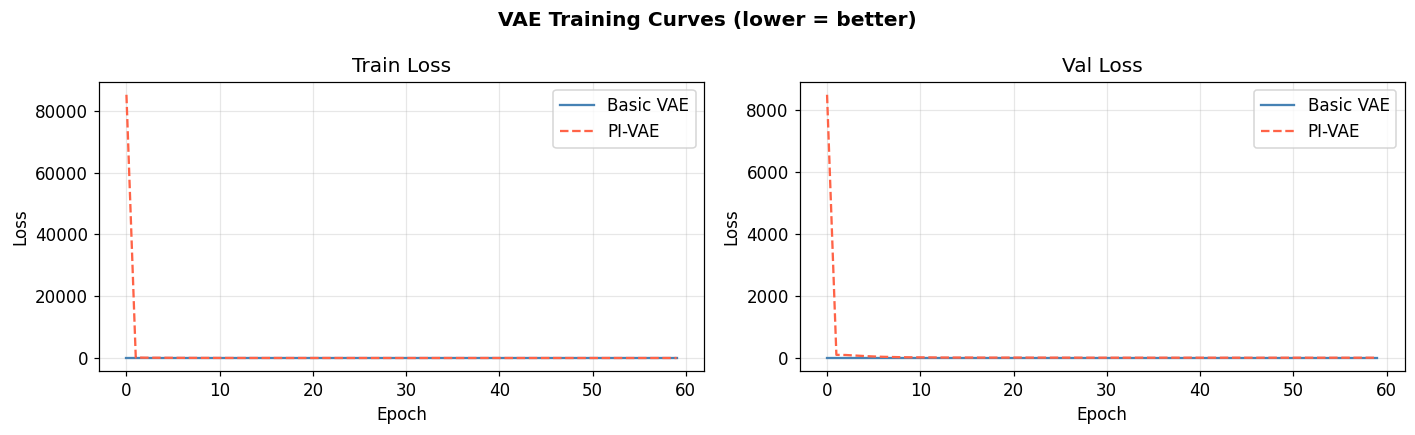

In [43]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, split in zip(axes, ['train', 'val']):
    ax.plot(hist_basic[split], label='Basic VAE',    color='steelblue')
    ax.plot(hist_phys[split],  label='PI-VAE',       color='tomato', linestyle='--')
    ax.set_title(f"{split.title()} Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
plt.suptitle("VAE Training Curves (lower = better)", fontweight='bold')
plt.tight_layout()
plt.show()

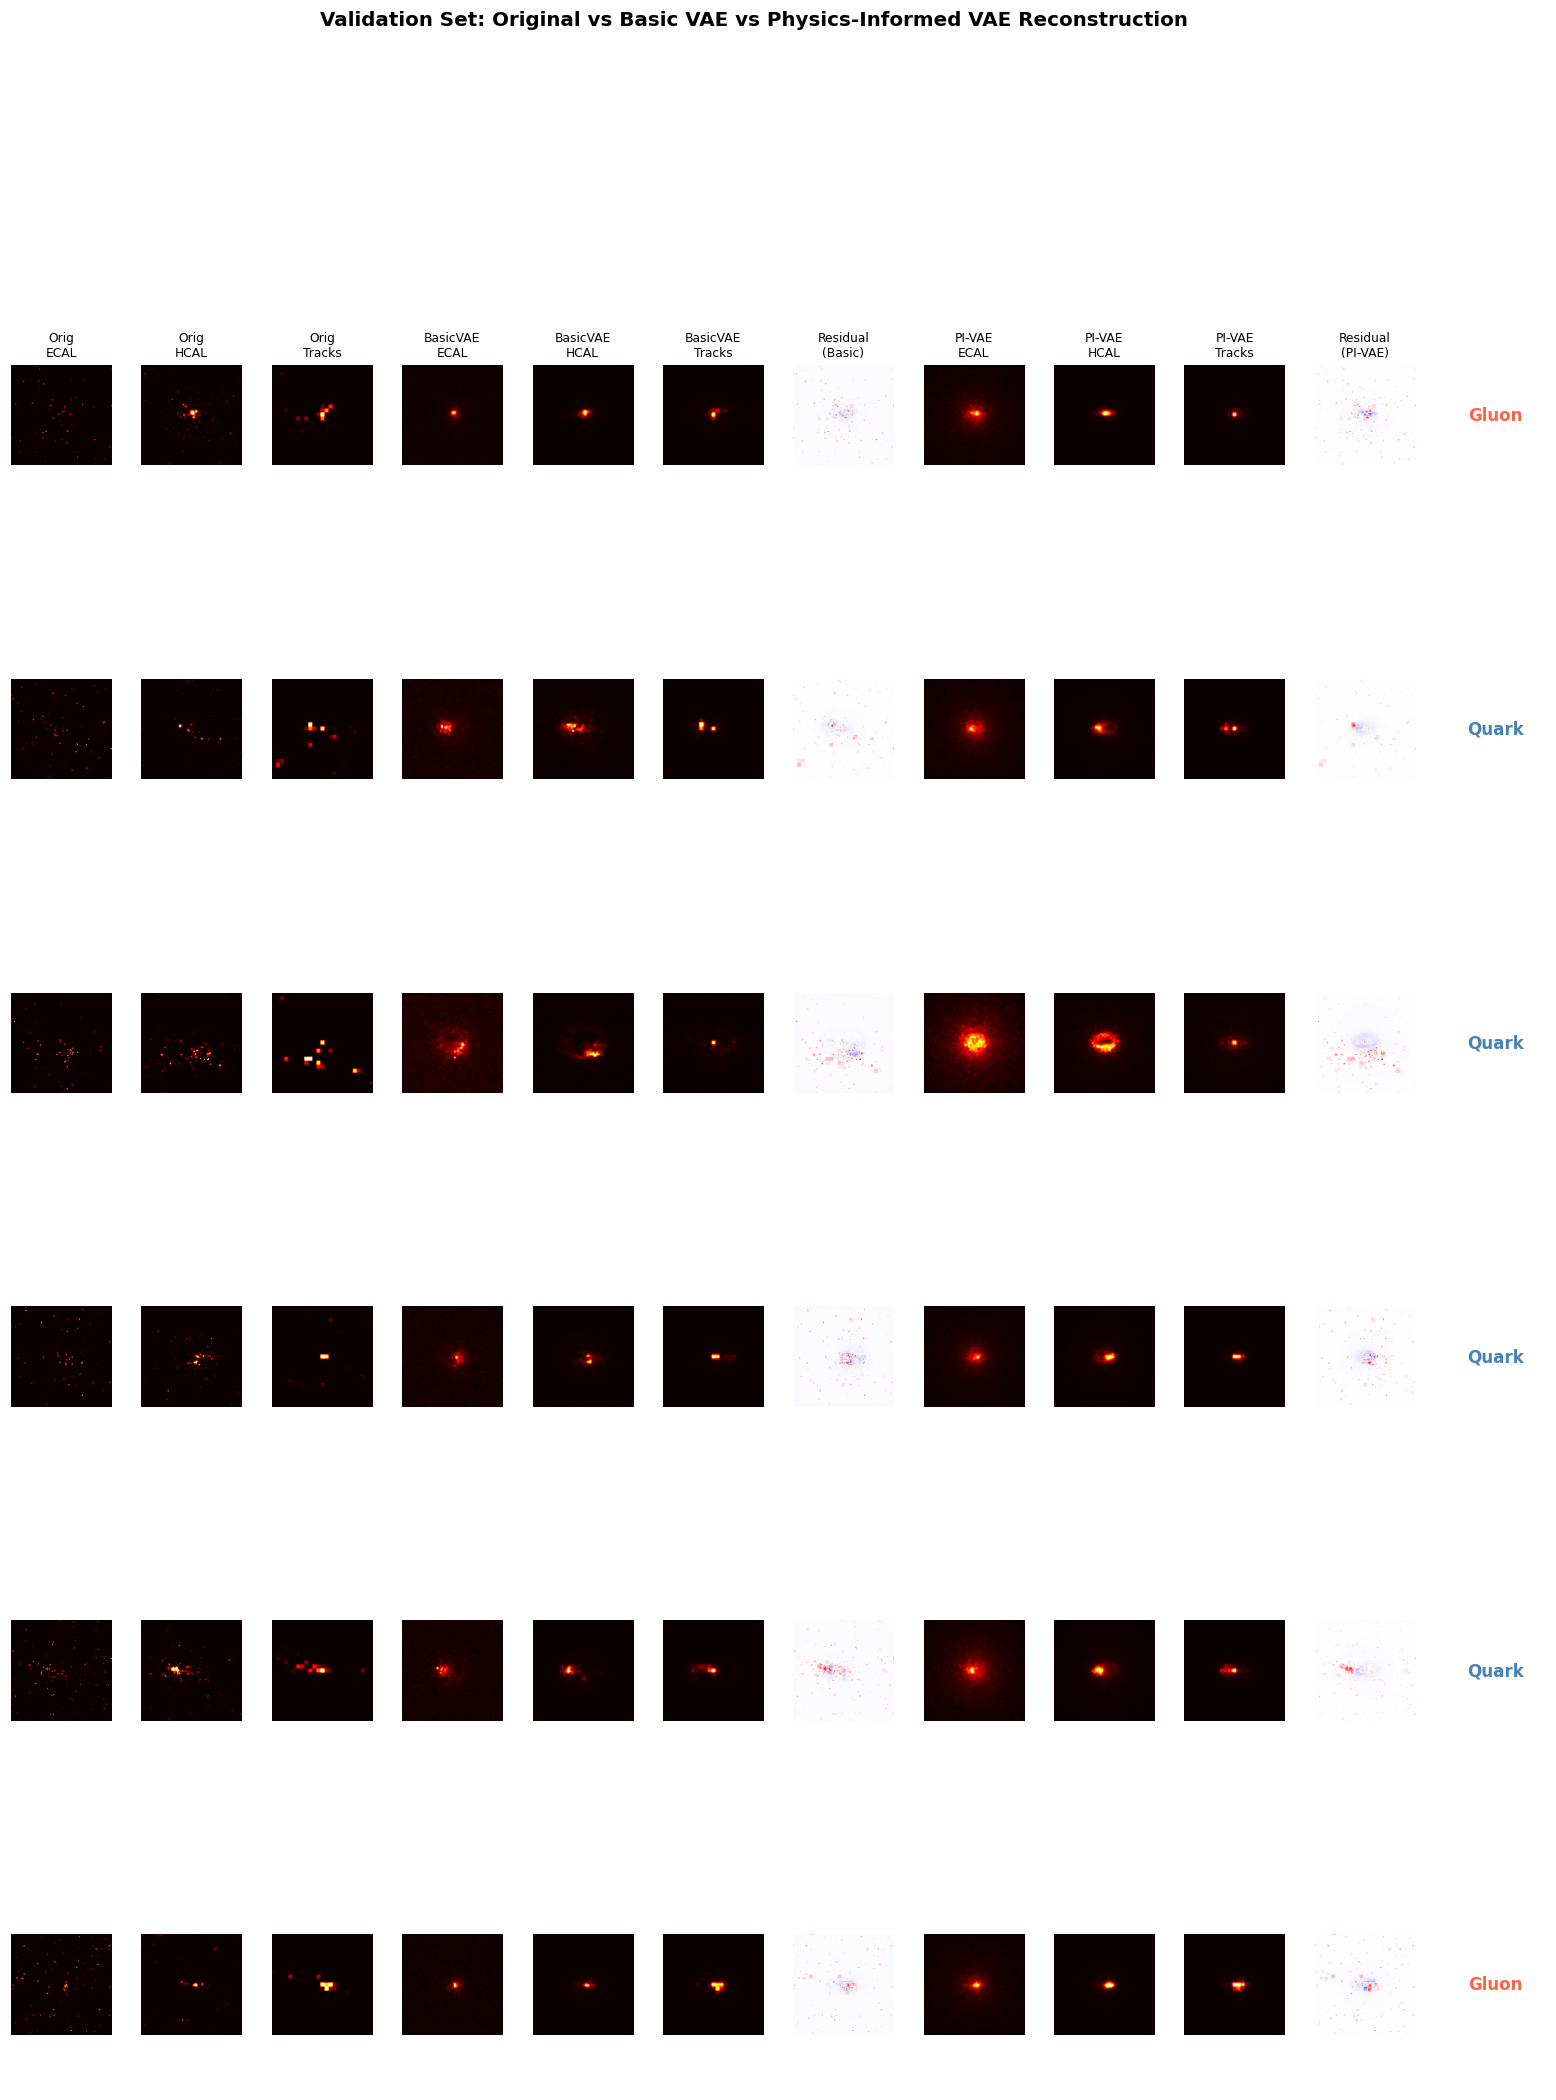

In [44]:
# ── VAE Reconstruction Comparison ────────────────────────────────────────────
# Collect a fixed batch from the validation set for comparison
vae_basic.eval(); vae_phys.eval()
val_batch = next(iter(loader_val))
x_val     = val_batch['image'][:CFG['N_VIS']].to(device)

with torch.no_grad():
    xr_basic, _, _ = vae_basic(x_val)
    xr_phys,  _, _ = vae_phys(x_val)

x_np      = x_val.cpu().numpy()
xr_b_np   = xr_basic.cpu().numpy()
xr_p_np   = xr_phys.cpu().numpy()

ch_names = ["ECAL", "HCAL", "Tracks"]
n        = CFG['N_VIS']
fig      = plt.figure(figsize=(18, 3.5 * n))
gs       = gridspec.GridSpec(n, 12, figure=fig, hspace=0.5, wspace=0.3)

for row in range(n):
    # Original (3 channels)
    for c, name in enumerate(ch_names):
        ax = fig.add_subplot(gs[row, c])
        ax.imshow(x_np[row, c], cmap='hot', origin='lower')
        if row == 0: ax.set_title(f"Orig\n{name}", fontsize=8)
        ax.axis('off')
    # Basic VAE (3 channels)
    for c, name in enumerate(ch_names):
        ax = fig.add_subplot(gs[row, 3 + c])
        ax.imshow(xr_b_np[row, c], cmap='hot', origin='lower')
        if row == 0: ax.set_title(f"BasicVAE\n{name}", fontsize=8)
        ax.axis('off')
    # Residuals basic
    ax = fig.add_subplot(gs[row, 6])
    diff = (x_np[row] - xr_b_np[row]).mean(0)
    im   = ax.imshow(diff, cmap='bwr', origin='lower',
                     vmin=-diff.max(), vmax=diff.max())
    if row == 0: ax.set_title("Residual\n(Basic)", fontsize=8)
    ax.axis('off')
    # Physics VAE (3 channels)
    for c, name in enumerate(ch_names):
        ax = fig.add_subplot(gs[row, 7 + c])
        ax.imshow(xr_p_np[row, c], cmap='hot', origin='lower')
        if row == 0: ax.set_title(f"PI-VAE\n{name}", fontsize=8)
        ax.axis('off')
    # Residuals physics
    ax = fig.add_subplot(gs[row, 10])
    diff_p = (x_np[row] - xr_p_np[row]).mean(0)
    ax.imshow(diff_p, cmap='bwr', origin='lower',
              vmin=-diff_p.max(), vmax=diff_p.max())
    if row == 0: ax.set_title("Residual\n(PI-VAE)", fontsize=8)
    ax.axis('off')
    # Label
    ax = fig.add_subplot(gs[row, 11])
    lbl_str = "Gluon" if val_batch['label'][row].item() else "Quark"
    ax.text(0.5, 0.5, lbl_str, ha='center', va='center',
            fontsize=11, fontweight='bold',
            color='tomato' if lbl_str == 'Gluon' else 'steelblue')
    ax.axis('off')

plt.suptitle("Validation Set: Original vs Basic VAE vs Physics-Informed VAE Reconstruction",
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig("vae_reconstruction_comparison.png", dpi=110, bbox_inches='tight')
plt.show()

In [45]:
# ── Quantitative VAE Metrics ──────────────────────────────────────────────────
# Compute MSE, SSIM-proxy (correlation), and physics-observable JS divergence
# over the full validation set


def ssim_proxy(a, b):
    """True SSIM (replaces Pearson correlation proxy)."""
    a_t = torch.from_numpy(a).unsqueeze(0).float()  # (1,C,H,W)
    b_t = torch.from_numpy(b).unsqueeze(0).float()
    return float(ssim(a_t, b_t, data_range=1.0).item())


def evaluate_vae_on_val(model, loader, physics_informed=False, lam=0.5):
    model.eval()
    mse_list, ssim_list = [], []
    obs_orig  = {'total_pt': [], 'jet_width': [], 'multiplicity': []}
    obs_recon = {'total_pt': [], 'jet_width': [], 'multiplicity': []}
    total_phys_loss = []

    with torch.no_grad():
        for batch in loader:
            x  = batch['image'].to(device)
            xr, mu, logvar = model(x)
            # MSE per sample
            mse = F.mse_loss(xr, x, reduction='none').mean(dim=[1,2,3])
            mse_list.extend(mse.cpu().numpy().tolist())
            # SSIM proxy per sample
            for i in range(x.size(0)):
                ssim_list.append(ssim_proxy(x[i].cpu().numpy(), xr[i].cpu().numpy()))
            # Physics observables
            o  = compute_jet_observables(x)
            or_ = compute_jet_observables(xr)
            for k in obs_orig:
                obs_orig[k].extend(o[k].cpu().numpy().tolist())
                obs_recon[k].extend(or_[k].cpu().numpy().tolist())
            if physics_informed:
                total_phys_loss.append(physics_loss(o, or_).item())

    results = {
        'MSE'  : np.mean(mse_list),
        'SSIM' : np.mean(ssim_list),
    }
    # Jensen-Shannon divergence for each observable
    for k in obs_orig:
        a = np.array(obs_orig[k]);  b = np.array(obs_recon[k])
        mn, mx = min(a.min(), b.min()), max(a.max(), b.max())
        bins   = np.linspace(mn, mx, 60)
        ha, _  = np.histogram(a, bins=bins, density=True)
        hb, _  = np.histogram(b, bins=bins, density=True)
        # Small epsilon to avoid log(0)
        ha += 1e-10; hb += 1e-10
        ha /= ha.sum(); hb /= hb.sum()
        results[f'JS_{k}']   = float(jensenshannon(ha, hb))
        results[f'WD_{k}']   = float(wasserstein_distance(a, b))
    if physics_informed:
        results['phys_loss'] = np.mean(total_phys_loss)
    return results


print("Evaluating Basic VAE on validation set …")
met_basic = evaluate_vae_on_val(vae_basic, loader_val, physics_informed=False)
print("Evaluating PI-VAE on validation set …")
met_phys  = evaluate_vae_on_val(vae_phys,  loader_val, physics_informed=True,
                                 lam=CFG['VAE_PHY_LAM'])

print("\n{'Metric':<30} {'Basic VAE':>12} {'PI-VAE':>12}")
print("-" * 56)
for k in met_basic:
    b_val = met_basic.get(k, float('nan'))
    p_val = met_phys.get(k,  float('nan'))
    print(f"  {k:<28} {b_val:12.5f} {p_val:12.5f}")

Evaluating Basic VAE on validation set …
Evaluating PI-VAE on validation set …

{'Metric':<30} {'Basic VAE':>12} {'PI-VAE':>12}
--------------------------------------------------------
  MSE                               0.00067      0.00080
  SSIM                              0.81527      0.85946
  JS_total_pt                       0.54728      0.23099
  WD_total_pt                      89.37661     25.38929
  JS_jet_width                      0.56213      0.19364
  WD_jet_width                      0.12748      0.01365
  JS_multiplicity                   0.17785      0.24732
  WD_multiplicity                  34.25333     50.65867


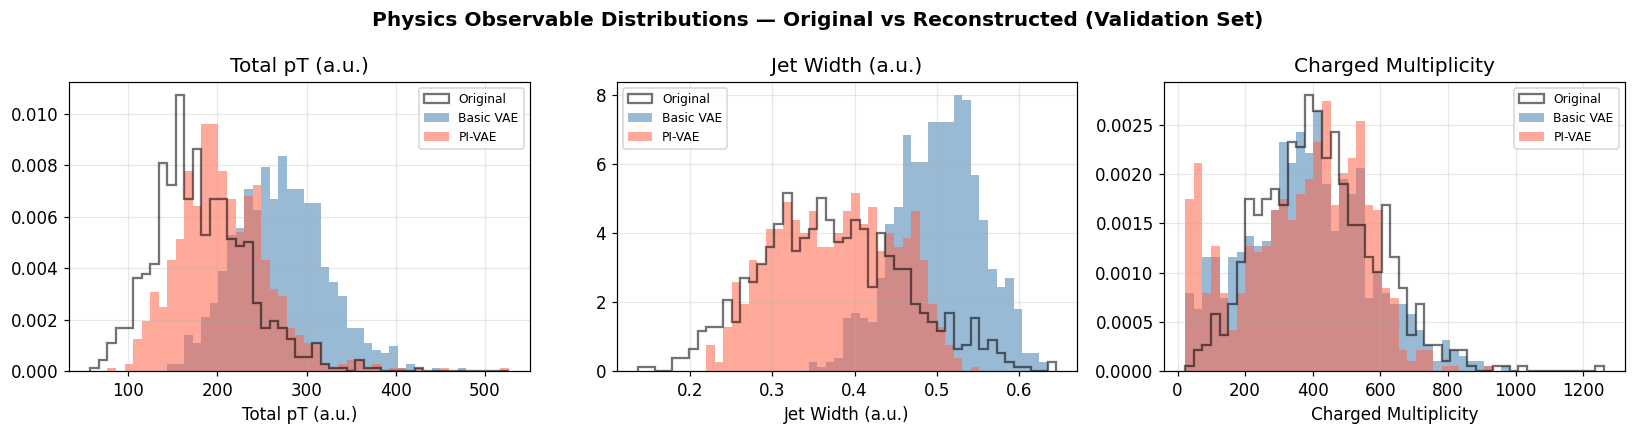

In [46]:
# ── Observable distribution plots (Basic VAE vs PI-VAE vs Original) ───────────
obs_keys  = ['total_pt', 'jet_width', 'multiplicity']
obs_labels = ['Total pT (a.u.)', 'Jet Width (a.u.)', 'Charged Multiplicity']

def gather_observables(model, loader):
    model.eval()
    orig_all  = {k: [] for k in obs_keys}
    recon_all = {k: [] for k in obs_keys}
    with torch.no_grad():
        for batch in loader:
            x = batch['image'].to(device)
            xr, _, _ = model(x)
            o  = compute_jet_observables(x)
            or_= compute_jet_observables(xr)
            for k in obs_keys:
                orig_all[k].extend(o[k].cpu().numpy().tolist())
                recon_all[k].extend(or_[k].cpu().numpy().tolist())
    return {k: np.array(orig_all[k]) for k in obs_keys}, \
           {k: np.array(recon_all[k]) for k in obs_keys}

orig_obs, recon_obs_b = gather_observables(vae_basic, loader_val)
_,         recon_obs_p = gather_observables(vae_phys,  loader_val)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, lbl in zip(axes, obs_keys, obs_labels):
    bins = np.linspace(
        min(orig_obs[key].min(), recon_obs_b[key].min(), recon_obs_p[key].min()),
        max(orig_obs[key].max(), recon_obs_b[key].max(), recon_obs_p[key].max()),
        50
    )
    ax.hist(orig_obs[key],    bins=bins, density=True, alpha=0.55,
            color='black',    label='Original',    histtype='step', linewidth=1.5)
    ax.hist(recon_obs_b[key], bins=bins, density=True, alpha=0.55,
            color='steelblue',label='Basic VAE',  histtype='stepfilled')
    ax.hist(recon_obs_p[key], bins=bins, density=True, alpha=0.55,
            color='tomato',   label='PI-VAE',     histtype='stepfilled')
    ax.set_xlabel(lbl); ax.set_title(lbl); ax.legend(fontsize=8)
plt.suptitle("Physics Observable Distributions — Original vs Reconstructed (Validation Set)",
             fontweight='bold')
plt.tight_layout()
plt.savefig("vae_physics_distributions.png", dpi=110, bbox_inches='tight')
plt.show()

## 5. Common Task 2 — Graph Neural Network Jet Classification

### From Images to Graphs
Each jet image is converted to a **point cloud** by retaining only non-zero pixels.
Each constituent (node) carries features:
- **η**, **φ** — (η-bin, φ-bin) coordinates in the image, normalised to [−1, 1]
- **E_ECAL**, **E_HCAL**, **E_tracks** — energy deposits per calorimeter channel

Edges are built by **k-nearest-neighbour** search in (η, φ) space using the
Euclidean metric, mimicking the angular proximity used in the ParticleNet
architecture [Qu & Gouskos 2020].

### Model — Dynamic Graph CNN (EdgeConv)
We use **Dynamic Edge Convolution** (DGCNN) [Wang et al. 2019]:
$$h_i = \max_{j \in \mathcal{N}(i)}\, \text{MLP}\!\left([h_i,\, h_j - h_i]\right)$$
The graph is rebuilt at each layer in the learned feature space (dynamic),
capturing multi-scale hierarchical structure analogous to jet substructure.

In [47]:
# ── Point cloud extraction ────────────────────────────────────────────────────
def image_to_pointcloud(image_nchw: np.ndarray, max_pts: int = 150,
                         threshold: float = 1e-3) -> np.ndarray:
    """
    Convert a (C, H, W) jet image to a (N_pts, 5) point cloud.

    Node features per constituent:
        [η_norm, φ_norm, E_ECAL, E_HCAL, E_track]

    Pixels with all-channel sum below `threshold` are background and discarded.
    """
    C, H, W = image_nchw.shape
    eta  = np.linspace(-1, 1, H)
    phi  = np.linspace(-1, 1, W)
    eta_g, phi_g = np.meshgrid(eta, phi, indexing='ij')   # (H, W)

    energy_sum = image_nchw.sum(0)         # (H, W)
    mask       = energy_sum > threshold
    if mask.sum() == 0:
        # Empty jet — return a single zero node
        return np.zeros((1, 5), dtype=np.float32)

    pts = np.stack([
        eta_g[mask],
        phi_g[mask],
        image_nchw[0][mask],   # ECAL
        image_nchw[1][mask],   # HCAL
        image_nchw[2][mask],   # Tracks
    ], axis=-1).astype(np.float32)   # (N_pts, 5)

    # Sort by descending energy and truncate
    order = np.argsort(-pts[:, 2:].sum(1))
    return pts[order[:max_pts]]


class JetGraphDataset(Dataset):
    """PyG-compatible dataset built from the JetDataset point clouds."""
    def __init__(self, jet_dataset: JetDataset, max_pts: int = 150):
        self.data_list = []
        for i in tqdm(range(len(jet_dataset)), desc="Building graph dataset", leave=False):
            item = jet_dataset[i]
            pc   = image_to_pointcloud(item['image'].numpy(), max_pts=max_pts)
            x    = torch.tensor(pc, dtype=torch.float32)          # (N_pts, 5)
            y    = item['label'].unsqueeze(0)                      # (1,)
            self.data_list.append(Data(x=x, y=y))

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        return self.data_list[idx]


print("Building graph datasets (this may take a minute) …")
gnn_ds_tr  = JetGraphDataset(ds_tr,  max_pts=CFG['GNN_MAX_PTS'])
gnn_ds_val = JetGraphDataset(ds_val, max_pts=CFG['GNN_MAX_PTS'])
gnn_ds_te  = JetGraphDataset(ds_te,  max_pts=CFG['GNN_MAX_PTS'])

gnn_loader_tr  = PyGDataLoader(gnn_ds_tr,  batch_size=CFG['GNN_BATCH'], shuffle=True)
gnn_loader_val = PyGDataLoader(gnn_ds_val, batch_size=CFG['GNN_BATCH'], shuffle=False)
gnn_loader_te  = PyGDataLoader(gnn_ds_te,  batch_size=CFG['GNN_BATCH'], shuffle=False)
print(f"Graph loaders ready. Sample: {gnn_ds_tr[0]}")

Building graph datasets (this may take a minute) …


Graph loaders ready. Sample: Data(x=[150, 5], y=[1])


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# -------- KNN (pure PyTorch) --------
def knn(x, k):
    # x: (N, F)
    dist = torch.cdist(x, x)              # (N, N)
    idx = dist.topk(k=k+1, largest=False)[1][:, 1:]  # exclude self
    return idx  # (N, k)


# -------- EdgeConv (no torch_cluster) --------
class EdgeConv(nn.Module):
    def __init__(self, mlp, k=12):
        super().__init__()
        self.mlp = mlp
        self.k = k

    def forward(self, x, batch):
        out = []

        for b in batch.unique():
            mask = (batch == b)
            xb = x[mask]                     # (Nb, F)

            idx = knn(xb, self.k)           # (Nb, k)

            Nb, F = xb.shape

            neighbors = xb[idx]             # (Nb, k, F)
            central   = xb.unsqueeze(1).expand(-1, self.k, -1)

            edge_feat = torch.cat([central, neighbors - central], dim=-1)  # (Nb,k,2F)

            edge_feat = edge_feat.reshape(-1, 2*F)
            edge_feat = self.mlp(edge_feat)
            edge_feat = edge_feat.view(Nb, self.k, -1)

            # max aggregation
            out.append(edge_feat.max(dim=1)[0])

        return torch.cat(out, dim=0)

In [48]:
# ── Graph FCN (Deep Sets–style) ───────────────────────────────────────────────
class SharedMLP(nn.Module):
    """Point-wise MLP applied independently to each node."""
    def __init__(self, dims, batch_norm=True):
        super().__init__()
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1], bias=not batch_norm))
            if batch_norm:
                layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(nn.GELU())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class JetGraphFCN(nn.Module):
    """
    Graph FCN (Deep Sets variant) for jet tagging.

    - No graph construction
    - No k-NN
    - No message passing
    - Permutation invariant
    """
    def __init__(self, in_features=5, num_classes=2):
        super().__init__()

        # Per-node feature extractor (φ)
        self.phi = SharedMLP([in_features, 64, 128, 256])

        # Global classifier (ρ)
        self.cls = nn.Sequential(
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 64),  nn.BatchNorm1d(64),  nn.GELU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, data):
        x, batch = data.x, data.batch  # x: (N_total, F)

        # Apply per-node MLP
        x = self.phi(x)  # (N_total, 256)

        # Global aggregation (max pool)
        out = []
        for b in batch.unique():
            xb = x[batch == b]
            out.append(xb.max(dim=0)[0])   # (256,)

        g = torch.stack(out)  # (B, 256)

        return self.cls(g)


# ── Instantiate ───────────────────────────────────────────────────────────────
print("Graph FCN model defined.")
gnn_model = JetGraphFCN(in_features=5, num_classes=2).to(device)
print(f"Model parameters: {sum(p.numel() for p in gnn_model.parameters()):,}")

Graph FCN model defined.
Model parameters: 125,186


In [49]:
# ── GNN training ──────────────────────────────────────────────────────────────
def train_gnn(model, loader_tr, loader_val, optimizer, epochs, scheduler=None):
    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
    criterion = nn.CrossEntropyLoss()

    for epoch in range(1, epochs + 1):
        model.train()
        tr_losses = []
        for data in loader_tr:
            data = data.to(device)
            logits = model(data)
            loss   = criterion(logits, data.y.squeeze())
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_losses.append(loss.item())

        model.eval()
        val_losses, all_probs, all_labels = [], [], []
        with torch.no_grad():
            for data in loader_val:
                data   = data.to(device)
                logits = model(data)
                loss   = criterion(logits, data.y.squeeze())
                val_losses.append(loss.item())
                probs  = logits.softmax(1)[:, 1].cpu().numpy()
                all_probs.extend(probs)
                all_labels.extend(data.y.squeeze().cpu().numpy())

        if scheduler: scheduler.step()
        auc = roc_auc_score(all_labels, all_probs)
        history['train_loss'].append(np.mean(tr_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['val_auc'].append(auc)

        if epoch % 5 == 0 or epoch == 1:
            print(f"[GNN] Epoch {epoch:3d}/{epochs}  "
                  f"TrainLoss={np.mean(tr_losses):.4f}  "
                  f"ValLoss={np.mean(val_losses):.4f}  AUC={auc:.4f}")
    return history


print("Training DGCNN …")
gnn_opt    = torch.optim.Adam(gnn_model.parameters(), lr=CFG['GNN_LR'], weight_decay=1e-6)
gnn_sched  = torch.optim.lr_scheduler.CosineAnnealingLR(gnn_opt, CFG['GNN_EPOCHS'])
gnn_hist   = train_gnn(gnn_model, gnn_loader_tr, gnn_loader_val,
                        gnn_opt, CFG['GNN_EPOCHS'], scheduler=gnn_sched)#CFG['GNN_EPOCHS']

Training DGCNN …
[GNN] Epoch   1/120  TrainLoss=0.7108  ValLoss=0.6916  AUC=0.5527
[GNN] Epoch   5/120  TrainLoss=0.6705  ValLoss=0.6645  AUC=0.6348
[GNN] Epoch  10/120  TrainLoss=0.6469  ValLoss=0.6527  AUC=0.6569
[GNN] Epoch  15/120  TrainLoss=0.6300  ValLoss=0.6455  AUC=0.6700
[GNN] Epoch  20/120  TrainLoss=0.6169  ValLoss=0.6435  AUC=0.6738
[GNN] Epoch  25/120  TrainLoss=0.6067  ValLoss=0.6405  AUC=0.6789
[GNN] Epoch  30/120  TrainLoss=0.5944  ValLoss=0.6397  AUC=0.6814
[GNN] Epoch  35/120  TrainLoss=0.5923  ValLoss=0.6346  AUC=0.6895
[GNN] Epoch  40/120  TrainLoss=0.5750  ValLoss=0.6356  AUC=0.6904
[GNN] Epoch  45/120  TrainLoss=0.5683  ValLoss=0.6361  AUC=0.6912
[GNN] Epoch  50/120  TrainLoss=0.5619  ValLoss=0.6327  AUC=0.6955
[GNN] Epoch  55/120  TrainLoss=0.5605  ValLoss=0.6334  AUC=0.6954
[GNN] Epoch  60/120  TrainLoss=0.5537  ValLoss=0.6333  AUC=0.6984
[GNN] Epoch  65/120  TrainLoss=0.5521  ValLoss=0.6349  AUC=0.6974
[GNN] Epoch  70/120  TrainLoss=0.5467  ValLoss=0.6333  AUC=


GNN Test Results:  AUC = 0.7006   Accuracy = 0.6547


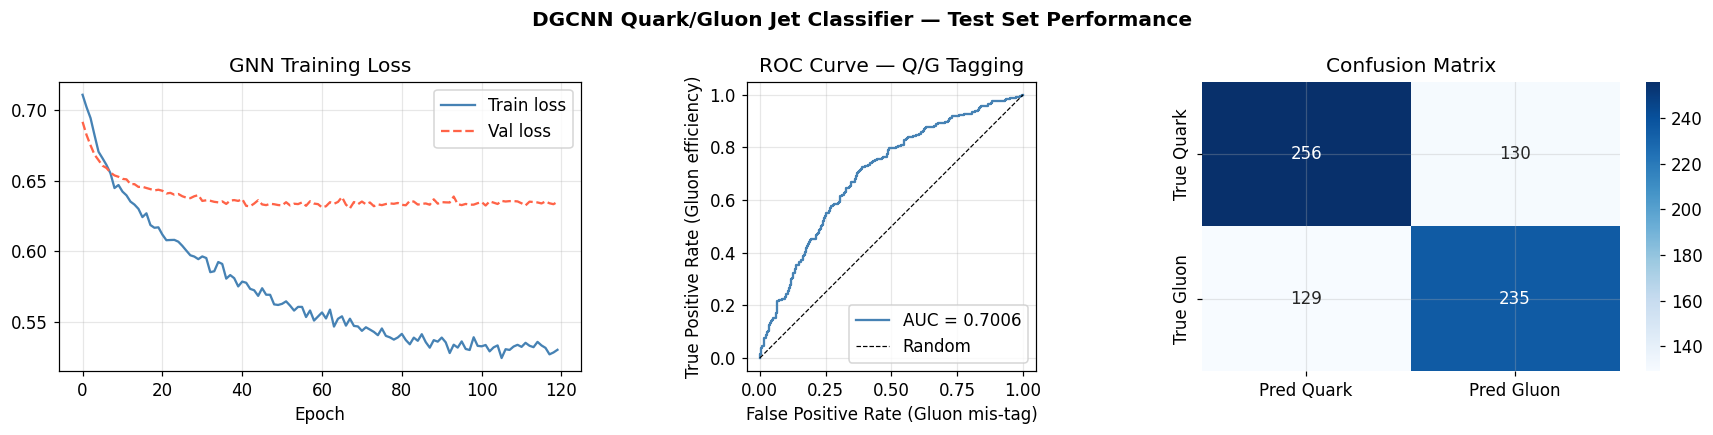

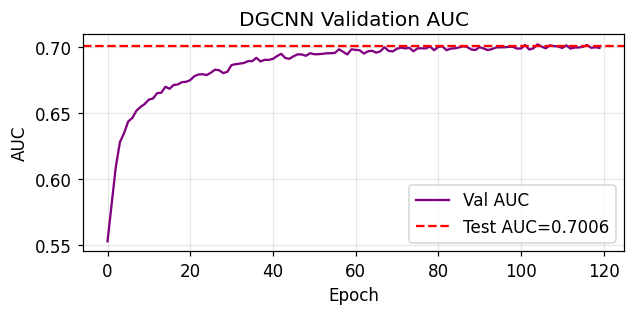

In [50]:
# ── GNN evaluation on test set ────────────────────────────────────────────────
gnn_model.eval()
test_probs, test_labels, test_preds = [], [], []
with torch.no_grad():
    for data in gnn_loader_te:
        data   = data.to(device)
        logits = gnn_model(data)
        probs  = logits.softmax(1)[:, 1].cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        test_probs.extend(probs)
        test_labels.extend(data.y.squeeze().cpu().numpy())
        test_preds.extend(preds)

test_labels = np.array(test_labels)
test_probs  = np.array(test_probs)
test_preds  = np.array(test_preds)

auc_test  = roc_auc_score(test_labels, test_probs)
acc_test  = accuracy_score(test_labels, test_preds)
cm        = confusion_matrix(test_labels, test_preds)
fpr, tpr, _ = roc_curve(test_labels, test_probs)

print(f"\nGNN Test Results:  AUC = {auc_test:.4f}   Accuracy = {acc_test:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
axes[0].plot(gnn_hist['train_loss'], label='Train loss', color='steelblue')
axes[0].plot(gnn_hist['val_loss'],   label='Val loss',   color='tomato', linestyle='--')
axes[0].set_xlabel("Epoch"); axes[0].set_title("GNN Training Loss"); axes[0].legend()

# ROC curve
axes[1].plot(fpr, tpr, color='steelblue', label=f"AUC = {auc_test:.4f}")
axes[1].plot([0,1],[0,1],'k--', linewidth=0.8, label='Random')
axes[1].set_xlabel("False Positive Rate (Gluon mis-tag)")
axes[1].set_ylabel("True Positive Rate (Gluon efficiency)")
axes[1].set_title("ROC Curve — Q/G Tagging")
axes[1].legend(); axes[1].set_aspect('equal')

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Quark','Pred Gluon'],
            yticklabels=['True Quark','True Gluon'], ax=axes[2])
axes[2].set_title("Confusion Matrix")
plt.suptitle("DGCNN Quark/Gluon Jet Classifier — Test Set Performance", fontweight='bold')
plt.tight_layout()
plt.savefig("gnn_evaluation.png", dpi=110, bbox_inches='tight')
plt.show()

# ── AUC vs epoch ────────────────────────────────────────────────────────────
plt.figure(figsize=(6, 3))
plt.plot(gnn_hist['val_auc'], color='purple', label='Val AUC')
plt.axhline(auc_test, color='red', linestyle='--', label=f'Test AUC={auc_test:.4f}')
plt.xlabel("Epoch"); plt.ylabel("AUC"); plt.title("DGCNN Validation AUC")
plt.legend(); plt.tight_layout()
plt.savefig("gnn_auc_curve.png", dpi=110, bbox_inches='tight')
plt.show()

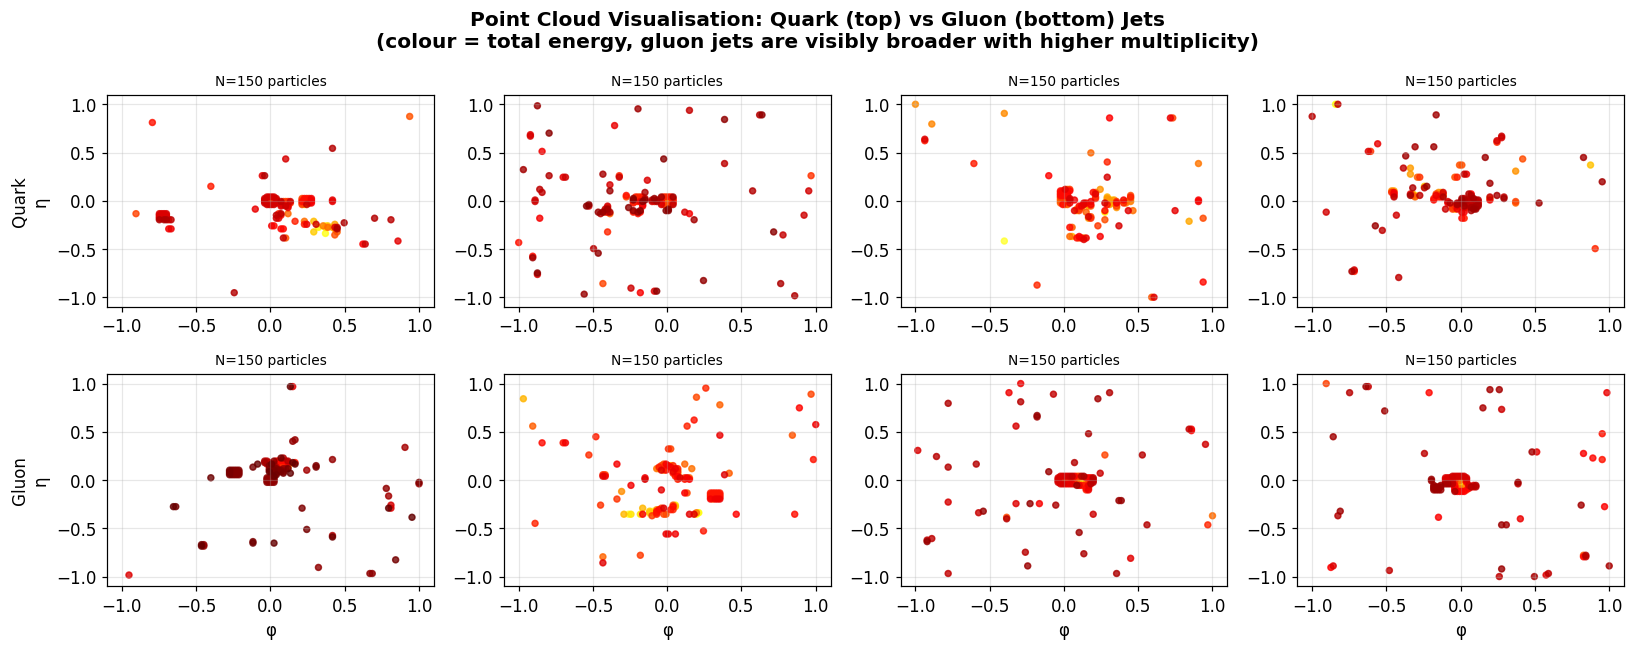

In [51]:
# ── Visualise point clouds ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for row, cls_name, cls_idx in zip([0, 1], ['Quark', 'Gluon'], [0, 1]):
    # Find 4 samples of this class
    cls_idxs = [i for i in range(len(gnn_ds_te))
                if gnn_ds_te[i].y.item() == cls_idx][:4]
    for col, i in enumerate(cls_idxs):
        pts = gnn_ds_te[i].x.numpy()   # (N, 5)
        sc  = axes[row, col].scatter(
            pts[:, 1], pts[:, 0],   # φ vs η
            c=pts[:, 2:].sum(1), cmap='hot', s=15, vmin=0, alpha=0.8
        )
        axes[row, col].set_xlim(-1.1, 1.1)
        axes[row, col].set_ylim(-1.1, 1.1)
        if col == 0:
            axes[row, col].set_ylabel(f"{cls_name}\nη")
        if row == 1:
            axes[row, col].set_xlabel("φ")
        axes[row, col].set_title(f"N={len(pts)} particles", fontsize=9)
plt.suptitle("Point Cloud Visualisation: Quark (top) vs Gluon (bottom) Jets\n"
             "(colour = total energy, gluon jets are visibly broader with higher multiplicity)",
             fontweight='bold')
plt.tight_layout()
plt.savefig("pointcloud_vis.png", dpi=110, bbox_inches='tight')
plt.show()

## 6. Specific Task 2 — Denoising Diffusion Probabilistic Models (DDPM)

### Forward (Noising) Process
Following Ho et al. (2020) [5], the forward process adds Gaussian noise over
T timesteps:
$$q(x_t | x_{t-1}) = \mathcal{N}(x_t;\, \sqrt{1-\beta_t}\, x_{t-1},\, \beta_t I)$$
With $\bar{\alpha}_t = \prod_{s=1}^t (1-\beta_s)$, we can sample directly:
$$x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \varepsilon, \quad \varepsilon \sim \mathcal{N}(0,I)$$

### Reverse (Denoising) Process
A U-Net $\varepsilon_\theta(x_t, t)$ is trained to predict the noise:
$$\mathcal{L}_{\text{DDPM}} = \mathbb{E}_{t,x_0,\varepsilon}\!\left[\|\varepsilon - \varepsilon_\theta(x_t,t)\|^2\right]$$

### Physics-Informed DDPM Extension
The model is **conditioned** on jet-level physics variables:
- **Jet class** (quark=0 / gluon=1) via a learnable embedding
- **Normalised jet mass** $\tilde{m}_0$ and **normalised pT** $\tilde{p}_T$

An auxiliary **physics denoising loss** adds pT and width conservation constraints:
$$\mathcal{L}_{\text{PI-DDPM}} = \mathcal{L}_{\text{DDPM}} + \lambda_{\text{phys}}\,
  \mathcal{L}_{\text{phys}}(\hat{x}_0, x_0)$$
where $\hat{x}_0$ is the model's estimate of the clean image at each step.

### Reconstruction via Partial Noising
To obtain a "reconstructed" image comparable to the VAE, we:
1. Forward-diffuse $x_0$ to an intermediate level $t^* = T/2$ (half-way noised)
2. Reverse-diffuse back to $t=0$ using the learned denoiser
This is an approximate reconstruction akin to DDIM inversion.

**Images are resized to 32×32** for computational feasibility. It is a Proof of Concept so it is not expected here to perform as well as the VAE

In [52]:
# ── Diffusion DataLoader (32×32 images) ───────────────────────────────────────
class DiffDataset(Dataset):
    """Wraps JetDataset, resizing images to diff_size for the DDPM."""
    def __init__(self, jet_dataset: JetDataset, diff_size: int = 32):
        self.base = jet_dataset
        self.sz   = diff_size

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        item = self.base[idx]
        img  = item['image']
        img  = F.interpolate(img.unsqueeze(0), size=self.sz,
                             mode='bilinear', align_corners=False).squeeze(0)
        return {'image': img, 'label': item['label'],
                'm0': item['m0'], 'pt': item['pt']}


diff_ds_tr  = DiffDataset(ds_tr,  CFG['DIFF_SIZE'])
diff_ds_val = DiffDataset(ds_val, CFG['DIFF_SIZE'])
diff_loader_tr  = DataLoader(diff_ds_tr,  batch_size=CFG['DIFF_BATCH'],
                              shuffle=True,  num_workers=0)
diff_loader_val = DataLoader(diff_ds_val, batch_size=CFG['DIFF_BATCH'],
                              shuffle=False, num_workers=0)
print(f"Diffusion dataset: image size = {CFG['DIFF_SIZE']}×{CFG['DIFF_SIZE']}")

Diffusion dataset: image size = 32×32


In [53]:
# ── Noise schedule & forward process ─────────────────────────────────────────
class DDPMScheduler:
    """
    Linear beta schedule as in Ho et al. (2020).
    Pre-computes cumulative products for efficient sampling.
    """
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.T       = T
        betas        = torch.linspace(beta_start, beta_end, T, device=device)
        alphas       = 1.0 - betas
        alpha_bar    = torch.cumprod(alphas, dim=0)
        alpha_bar_prev = torch.cat([torch.ones(1, device=device), alpha_bar[:-1]])

        self.betas       = betas
        self.alphas      = alphas
        self.alpha_bar   = alpha_bar
        self.alpha_bar_prev = alpha_bar_prev
        self.sqrt_ab     = alpha_bar.sqrt()
        self.sqrt_1mab   = (1 - alpha_bar).sqrt()
        self.posterior_var = betas * (1 - alpha_bar_prev) / (1 - alpha_bar)

    def q_sample(self, x0, t, noise=None):
        """Sample x_t ~ q(x_t|x_0) in one step."""
        if noise is None:
            noise = torch.randn_like(x0)
        s_ab  = self.sqrt_ab[t].view(-1, 1, 1, 1)
        s_1mab = self.sqrt_1mab[t].view(-1, 1, 1, 1)
        return s_ab * x0 + s_1mab * noise, noise

    @torch.no_grad()
    def p_sample(self, model, xt, t_int, cond=None):
        """Single reverse step p(x_{t-1}|x_t)."""
        t_tensor = torch.full((xt.size(0),), t_int, device=xt.device, dtype=torch.long)
        eps_pred = model(xt, t_tensor, cond=cond)
        alpha   = self.alphas[t_int]
        ab      = self.alpha_bar[t_int]
        ab_prev = self.alpha_bar_prev[t_int]
        # Estimate x0
        x0_hat  = (xt - self.sqrt_1mab[t_int] * eps_pred) / self.sqrt_ab[t_int]
        x0_hat  = x0_hat.clamp(0, 1)
        # Posterior mean
        coef1   = (ab_prev.sqrt() * self.betas[t_int]) / (1 - ab)
        coef2   = ((1 - ab_prev) * alpha.sqrt()) / (1 - ab)
        mean    = coef1 * x0_hat + coef2 * xt
        var     = self.posterior_var[t_int]
        noise   = torch.randn_like(xt) if t_int > 0 else torch.zeros_like(xt)
        return mean + var.sqrt() * noise, x0_hat

    @torch.no_grad()
    def reconstruct(self, model, x0, t_star=None, cond=None):
        """
        Approximate reconstruction via partial noising + denoising.
        Forward-diffuse x0 to t_star, then reverse-diffuse to 0.
        """
        if t_star is None:
            t_star = self.T // 2
        t_tensor = torch.full((x0.size(0),), t_star - 1, device=x0.device, dtype=torch.long)
        xt, _ = self.q_sample(x0, t_tensor)
        for t in reversed(range(t_star)):
            xt, _ = self.p_sample(model, xt, t, cond=cond)
        return xt


sched = DDPMScheduler(T=CFG['DIFF_T'], device=device)
print(f"DDPM scheduler ready. T={CFG['DIFF_T']}, β ∈ [{sched.betas[0]:.1e}, {sched.betas[-1]:.3f}]")

DDPM scheduler ready. T=500, β ∈ [1.0e-04, 0.020]


In [54]:
# ── U-Net building blocks ─────────────────────────────────────────────────────
class SinusoidalEmb(nn.Module):
    """Sinusoidal time-step positional embedding (Vaswani et al. 2017)."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device).float() / half
        )
        args  = t[:, None].float() * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)   # (B, dim)


class ResBlock(nn.Module):
    """Residual block with optional time embedding and optional group-norm."""
    def __init__(self, in_ch, out_ch, time_dim=None, cond_dim=None, groups=8):
        super().__init__()
        self.in_ch  = in_ch
        self.out_ch = out_ch
        self.norm1  = nn.GroupNorm(groups, in_ch)
        self.conv1  = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2  = nn.GroupNorm(groups, out_ch)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.act    = nn.SiLU()
        self.skip   = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        # Optional conditioning projections
        self.time_proj = nn.Linear(time_dim, out_ch) if time_dim else None
        self.cond_proj = nn.Linear(cond_dim, out_ch) if cond_dim else None

    def forward(self, x, t_emb=None, cond_emb=None):
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        if t_emb is not None and self.time_proj is not None:
            h = h + self.time_proj(self.act(t_emb))[:, :, None, None]
        if cond_emb is not None and self.cond_proj is not None:
            h = h + self.cond_proj(self.act(cond_emb))[:, :, None, None]
        h = self.conv2(self.act(self.norm2(h)))
        return h + self.skip(x)


class AttentionBlock(nn.Module):
    """Lightweight spatial self-attention (used at the bottleneck)."""
    def __init__(self, ch, groups=8):
        super().__init__()
        self.norm = nn.GroupNorm(groups, ch)
        self.qkv  = nn.Conv2d(ch, 3 * ch, 1)
        self.proj = nn.Conv2d(ch, ch, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h   = self.norm(x)
        qkv = self.qkv(h).view(B, 3, C, H * W)
        q, k, v = qkv.unbind(dim=1)    # each (B, C, H*W)
        scale  = C ** -0.5
        attn   = torch.softmax(q.transpose(-2, -1) @ k * scale, dim=-1)  # (B,HW,HW)
        out    = (attn @ v.transpose(-2, -1)).transpose(-2, -1)           # (B,C,HW)
        return x + self.proj(out.view(B, C, H, W))


class SimpleUNet(nn.Module):
    """
    U-Net denoiser for the DDPM.

    Architecture (32×32 input):
        Enc: 32→16→8  (stride-2 downsampling)
        Mid: 8        (ResBlock + Attention + ResBlock)
        Dec: 8→16→32  (bilinear upsampling + skip connections)

    Optional conditioning:
        - Sinusoidal time embedding (always present)
        - Physics condition: class + normalised m0 + normalised pT
    """
    def __init__(self, in_ch=3, base_ch=64, time_dim=128,
                 cond_dim=None, ch_mults=(1, 2, 4)):
        super().__init__()
        self.cond_dim = cond_dim
        dims   = [base_ch * m for m in ch_mults]   # e.g. [64, 128, 256]
        self.time_mlp = nn.Sequential(
            SinusoidalEmb(time_dim),
            nn.Linear(time_dim, time_dim * 2), nn.SiLU(),
            nn.Linear(time_dim * 2, time_dim),
        )
        # Encoder
        self.init_conv = nn.Conv2d(in_ch, dims[0], 3, padding=1)
        self.down1 = ResBlock(dims[0], dims[0], time_dim, cond_dim, groups=8)
        self.pool1 = nn.Conv2d(dims[0], dims[0], 4, stride=2, padding=1)   # 32→16
        self.down2 = ResBlock(dims[0], dims[1], time_dim, cond_dim, groups=8)
        self.pool2 = nn.Conv2d(dims[1], dims[1], 4, stride=2, padding=1)   # 16→8
        # Bottleneck
        self.mid1 = ResBlock(dims[1], dims[2], time_dim, cond_dim, groups=8)
        self.attn = AttentionBlock(dims[2], groups=8)
        self.mid2 = ResBlock(dims[2], dims[1], time_dim, cond_dim, groups=8)
        # Decoder
        self.up1  = nn.ConvTranspose2d(dims[1], dims[1], 4, stride=2, padding=1)  # 8→16
        self.dec1 = ResBlock(dims[1]*2, dims[0], time_dim, cond_dim, groups=8)    # skip from down2
        self.up2  = nn.ConvTranspose2d(dims[0], dims[0], 4, stride=2, padding=1)  # 16→32
        self.dec2 = ResBlock(dims[0]*2, dims[0], time_dim, cond_dim, groups=8)    # skip from down1
        # Output
        self.out  = nn.Sequential(
            nn.GroupNorm(8, dims[0]), nn.SiLU(),
            nn.Conv2d(dims[0], in_ch, 1)
        )

    def forward(self, x, t, cond=None):
        te = self.time_mlp(t)
        h0 = self.init_conv(x)           # (B, 64, 32, 32)
        h1 = self.down1(h0, te, cond)    # (B, 64, 32, 32)
        h  = self.pool1(h1)              # (B, 64, 16, 16)
        h2 = self.down2(h,  te, cond)    # (B,128, 16, 16)
        h  = self.pool2(h2)              # (B,128,  8,  8)
        h  = self.mid1(h,   te, cond)    # (B,256,  8,  8)
        h  = self.attn(h)
        h  = self.mid2(h,   te, cond)    # (B,128,  8,  8)
        h  = self.up1(h)                 # (B,128, 16, 16)
        h  = self.dec1(torch.cat([h, h2], 1), te, cond)  # skip
        h  = self.up2(h)                 # (B, 64, 32, 32)
        h  = self.dec2(torch.cat([h, h1], 1), te, cond)  # skip
        return self.out(h)               # (B, 3, 32, 32)


class PhysicsConditioner(nn.Module):
    """
    Encodes physics conditioning variables into an embedding vector.
    Inputs: class label, normalised m0, normalised pT.
    """
    def __init__(self, num_classes=2, cond_dim=64):
        super().__init__()
        self.cls_emb = nn.Embedding(num_classes, 32)
        self.phy_mlp = nn.Sequential(
            nn.Linear(2, 32), nn.SiLU(),
            nn.Linear(32, 32),
        )
        self.proj = nn.Linear(64, cond_dim)

    def forward(self, label, m0_norm, pt_norm):
        c_emb = self.cls_emb(label)
        p_emb = self.phy_mlp(torch.stack([m0_norm, pt_norm], dim=-1))
        return self.proj(torch.cat([c_emb, p_emb], dim=-1))


print("U-Net and conditioning modules defined.")

U-Net and conditioning modules defined.


In [55]:
# ── Instantiate models ────────────────────────────────────────────────────────
COND_DIM = 64   # physics conditioning embedding size

# Basic DDPM (no conditioning)
ddpm_basic = SimpleUNet(in_ch=3, base_ch=64, time_dim=128,
                        cond_dim=None).to(device)

# Physics-Informed DDPM (conditioned on class + m0 + pT)
ddpm_phys  = SimpleUNet(in_ch=3, base_ch=64, time_dim=128,
                        cond_dim=COND_DIM).to(device)
conditioner = PhysicsConditioner(num_classes=2, cond_dim=COND_DIM).to(device)

n_basic = sum(p.numel() for p in ddpm_basic.parameters())
n_phys  = sum(p.numel() for p in ddpm_phys.parameters()) + \
          sum(p.numel() for p in conditioner.parameters())
print(f"Basic DDPM:  {n_basic:,} parameters")
print(f"PI-DDPM:     {n_phys:,} parameters")

# ──  Normalise m0 and pT for conditioning ────────────────────────────────────
all_m0_tr = np.array([ds_tr[i]['m0'].item() for i in range(len(ds_tr))])
all_pt_tr = np.array([ds_tr[i]['pt'].item() for i in range(len(ds_tr))])
m0_mu, m0_std = float(all_m0_tr.mean()), float(all_m0_tr.std() + 1e-8)
pt_mu, pt_std = float(all_pt_tr.mean()), float(all_pt_tr.std() + 1e-8)

def normalise_physics(m0, pt):
    """Standardise m0 and pT to zero mean, unit variance."""
    return (m0 - m0_mu) / m0_std, (pt - pt_mu) / pt_std

Basic DDPM:  3,098,755 parameters
PI-DDPM:     3,149,891 parameters


In [56]:
# ── Generic DDPM training function ───────────────────────────────────────────
def train_ddpm(model, loader_tr, loader_val, scheduler_obj,
               optimizer, epochs, physics_informed=False,
               cond_net=None, lam_phys=0.1, label="DDPM"):
    """
    Train a DDPM model.

    For physics-informed mode: also compute an auxiliary physics loss on
    the model's estimate of the clean image x0_hat at each step.
    """
    history = {'train': [], 'val': []}
    for epoch in range(1, epochs + 1):
        model.train()
        if cond_net: cond_net.train()
        tr_losses = []

        for batch in loader_tr:
            x     = batch['image'].to(device)
            B     = x.size(0)
            t     = torch.randint(0, scheduler_obj.T, (B,), device=device)
            xt, noise = scheduler_obj.q_sample(x, t)

            # Build conditioning (physics-informed mode only)
            cond = None
            if physics_informed and cond_net is not None:
                m0n, ptn = normalise_physics(
                    batch['m0'].to(device), batch['pt'].to(device)
                )
                cond = cond_net(batch['label'].to(device), m0n, ptn)

            eps_pred = model(xt, t, cond=cond)
            ddpm_loss = F.mse_loss(eps_pred, noise)

            total_loss = ddpm_loss
            if physics_informed:
                # Estimate x0 from the predicted noise for physics loss
                x0_hat = (xt - scheduler_obj.sqrt_1mab[t].view(-1,1,1,1) * eps_pred) \
                         / scheduler_obj.sqrt_ab[t].view(-1,1,1,1).clamp(min=1e-6)
                x0_hat = x0_hat.clamp(0, 1)
                orig_obs  = compute_jet_observables(x)
                recon_obs = compute_jet_observables(x0_hat)
                total_loss = ddpm_loss + lam_phys * physics_loss(orig_obs, recon_obs)

            optimizer.zero_grad()
            total_loss.backward()
            nn.utils.clip_grad_norm_(list(model.parameters()) +
                                      (list(cond_net.parameters()) if cond_net else []), 1.0)
            optimizer.step()
            tr_losses.append(total_loss.item())

        # Validation
        model.eval()
        if cond_net: cond_net.eval()
        val_losses = []
        with torch.no_grad():
            for batch in loader_val:
                x  = batch['image'].to(device)
                B  = x.size(0)
                t  = torch.randint(0, scheduler_obj.T, (B,), device=device)
                xt, noise = scheduler_obj.q_sample(x, t)
                cond = None
                if physics_informed and cond_net is not None:
                    m0n, ptn = normalise_physics(
                        batch['m0'].to(device), batch['pt'].to(device))
                    cond = cond_net(batch['label'].to(device), m0n, ptn)
                eps_pred = model(xt, t, cond=cond)
                loss = F.mse_loss(eps_pred, noise)
                val_losses.append(loss.item())

        tr_m  = np.mean(tr_losses)
        val_m = np.mean(val_losses)
        history['train'].append(tr_m)
        history['val'].append(val_m)
        if epoch % 5 == 0 or epoch == 1:
            print(f"[{label}] Epoch {epoch:3d}/{epochs}  "
                  f"Train={tr_m:.5f}  Val={val_m:.5f}")
    return history


print("Training Basic DDPM …")
print("=" * 60)
opt_ddpm_b = torch.optim.Adam(ddpm_basic.parameters(), lr=CFG['DIFF_LR'])
hist_ddpm_b = train_ddpm(ddpm_basic, diff_loader_tr, diff_loader_val, sched,
                          opt_ddpm_b, CFG['DIFF_EPOCHS'],
                          physics_informed=False, label="Basic DDPM")

print("\nTraining Physics-Informed DDPM …")
print("=" * 60)
opt_ddpm_p = torch.optim.Adam(
    list(ddpm_phys.parameters()) + list(conditioner.parameters()),
    lr=CFG['DIFF_LR'])
hist_ddpm_p = train_ddpm(ddpm_phys, diff_loader_tr, diff_loader_val, sched,
                          opt_ddpm_p, CFG['DIFF_EPOCHS'],
                          physics_informed=True, cond_net=conditioner,
                          lam_phys=0.005, label="PI-DDPM")

Training Basic DDPM …
[Basic DDPM] Epoch   1/100  Train=0.20639  Val=0.04254
[Basic DDPM] Epoch   5/100  Train=0.01441  Val=0.01484
[Basic DDPM] Epoch  10/100  Train=0.00863  Val=0.00735
[Basic DDPM] Epoch  15/100  Train=0.00753  Val=0.00689
[Basic DDPM] Epoch  20/100  Train=0.00657  Val=0.00695
[Basic DDPM] Epoch  25/100  Train=0.00589  Val=0.00617
[Basic DDPM] Epoch  30/100  Train=0.00586  Val=0.00503
[Basic DDPM] Epoch  35/100  Train=0.00513  Val=0.00518
[Basic DDPM] Epoch  40/100  Train=0.00498  Val=0.00399
[Basic DDPM] Epoch  45/100  Train=0.00539  Val=0.00468
[Basic DDPM] Epoch  50/100  Train=0.00496  Val=0.00484
[Basic DDPM] Epoch  55/100  Train=0.00593  Val=0.00422
[Basic DDPM] Epoch  60/100  Train=0.00494  Val=0.00363
[Basic DDPM] Epoch  65/100  Train=0.00469  Val=0.00345
[Basic DDPM] Epoch  70/100  Train=0.00451  Val=0.00471
[Basic DDPM] Epoch  75/100  Train=0.00421  Val=0.00378
[Basic DDPM] Epoch  80/100  Train=0.00459  Val=0.00446
[Basic DDPM] Epoch  85/100  Train=0.00385  

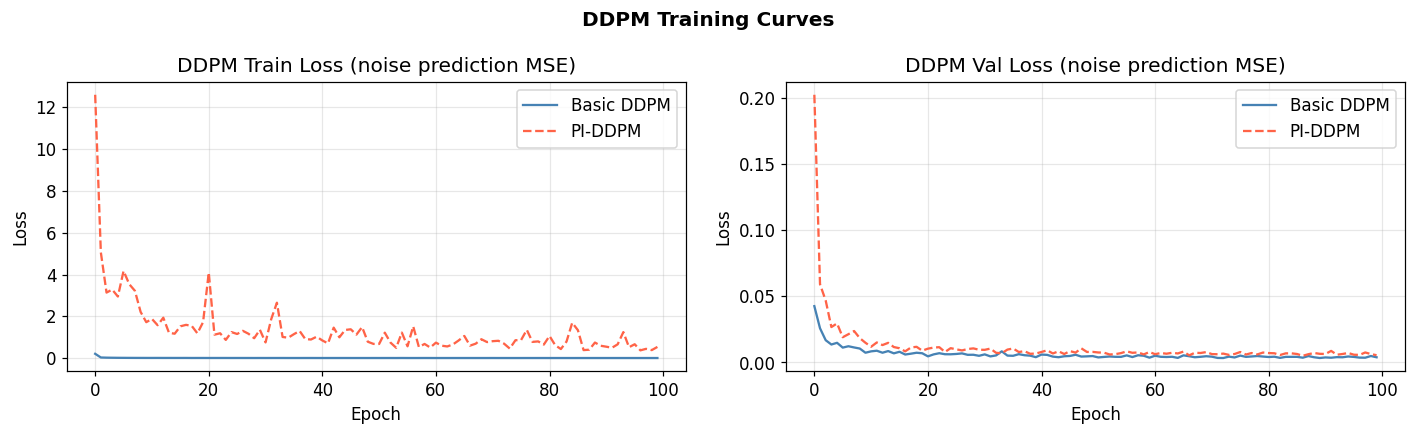

In [57]:
# ── DDPM Training Curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, split in zip(axes, ['train', 'val']):
    ax.plot(hist_ddpm_b[split], label='Basic DDPM',  color='steelblue')
    ax.plot(hist_ddpm_p[split], label='PI-DDPM',     color='tomato', linestyle='--')
    ax.set_title(f"DDPM {split.title()} Loss (noise prediction MSE)")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()
plt.suptitle("DDPM Training Curves", fontweight='bold')
plt.tight_layout()
plt.savefig("ddpm_training_curves.png", dpi=110, bbox_inches='tight')
plt.show()

In [58]:
# ── DDPM Reconstruction on Validation Set ────────────────────────────────────
# Take N_VIS samples and reconstruct via partial-noise + denoise
ddpm_basic.eval(); ddpm_phys.eval(); conditioner.eval()

val_diff_batch = next(iter(diff_loader_val))
x0_val   = val_diff_batch['image'][:CFG['N_VIS']].to(device)
lbl_val  = val_diff_batch['label'][:CFG['N_VIS']].to(device)
m0_val   = val_diff_batch['m0'][:CFG['N_VIS']].to(device)
pt_val   = val_diff_batch['pt'][:CFG['N_VIS']].to(device)

T_STAR = CFG['DIFF_T'] // 2   # noise up to halfway, then denoise

with torch.no_grad():
    # Basic DDPM reconstruction (no conditioning)
    xr_ddpm_b = sched.reconstruct(ddpm_basic, x0_val, t_star=T_STAR, cond=None)
    # PI-DDPM reconstruction (with physics conditioning)
    m0n, ptn  = normalise_physics(m0_val, pt_val)
    cond_val  = conditioner(lbl_val, m0n, ptn)
    xr_ddpm_p = sched.reconstruct(ddpm_phys, x0_val, t_star=T_STAR, cond=cond_val)

x0_np   = x0_val.cpu().numpy()
xrb_np  = xr_ddpm_b.cpu().numpy()
xrp_np  = xr_ddpm_p.cpu().numpy()

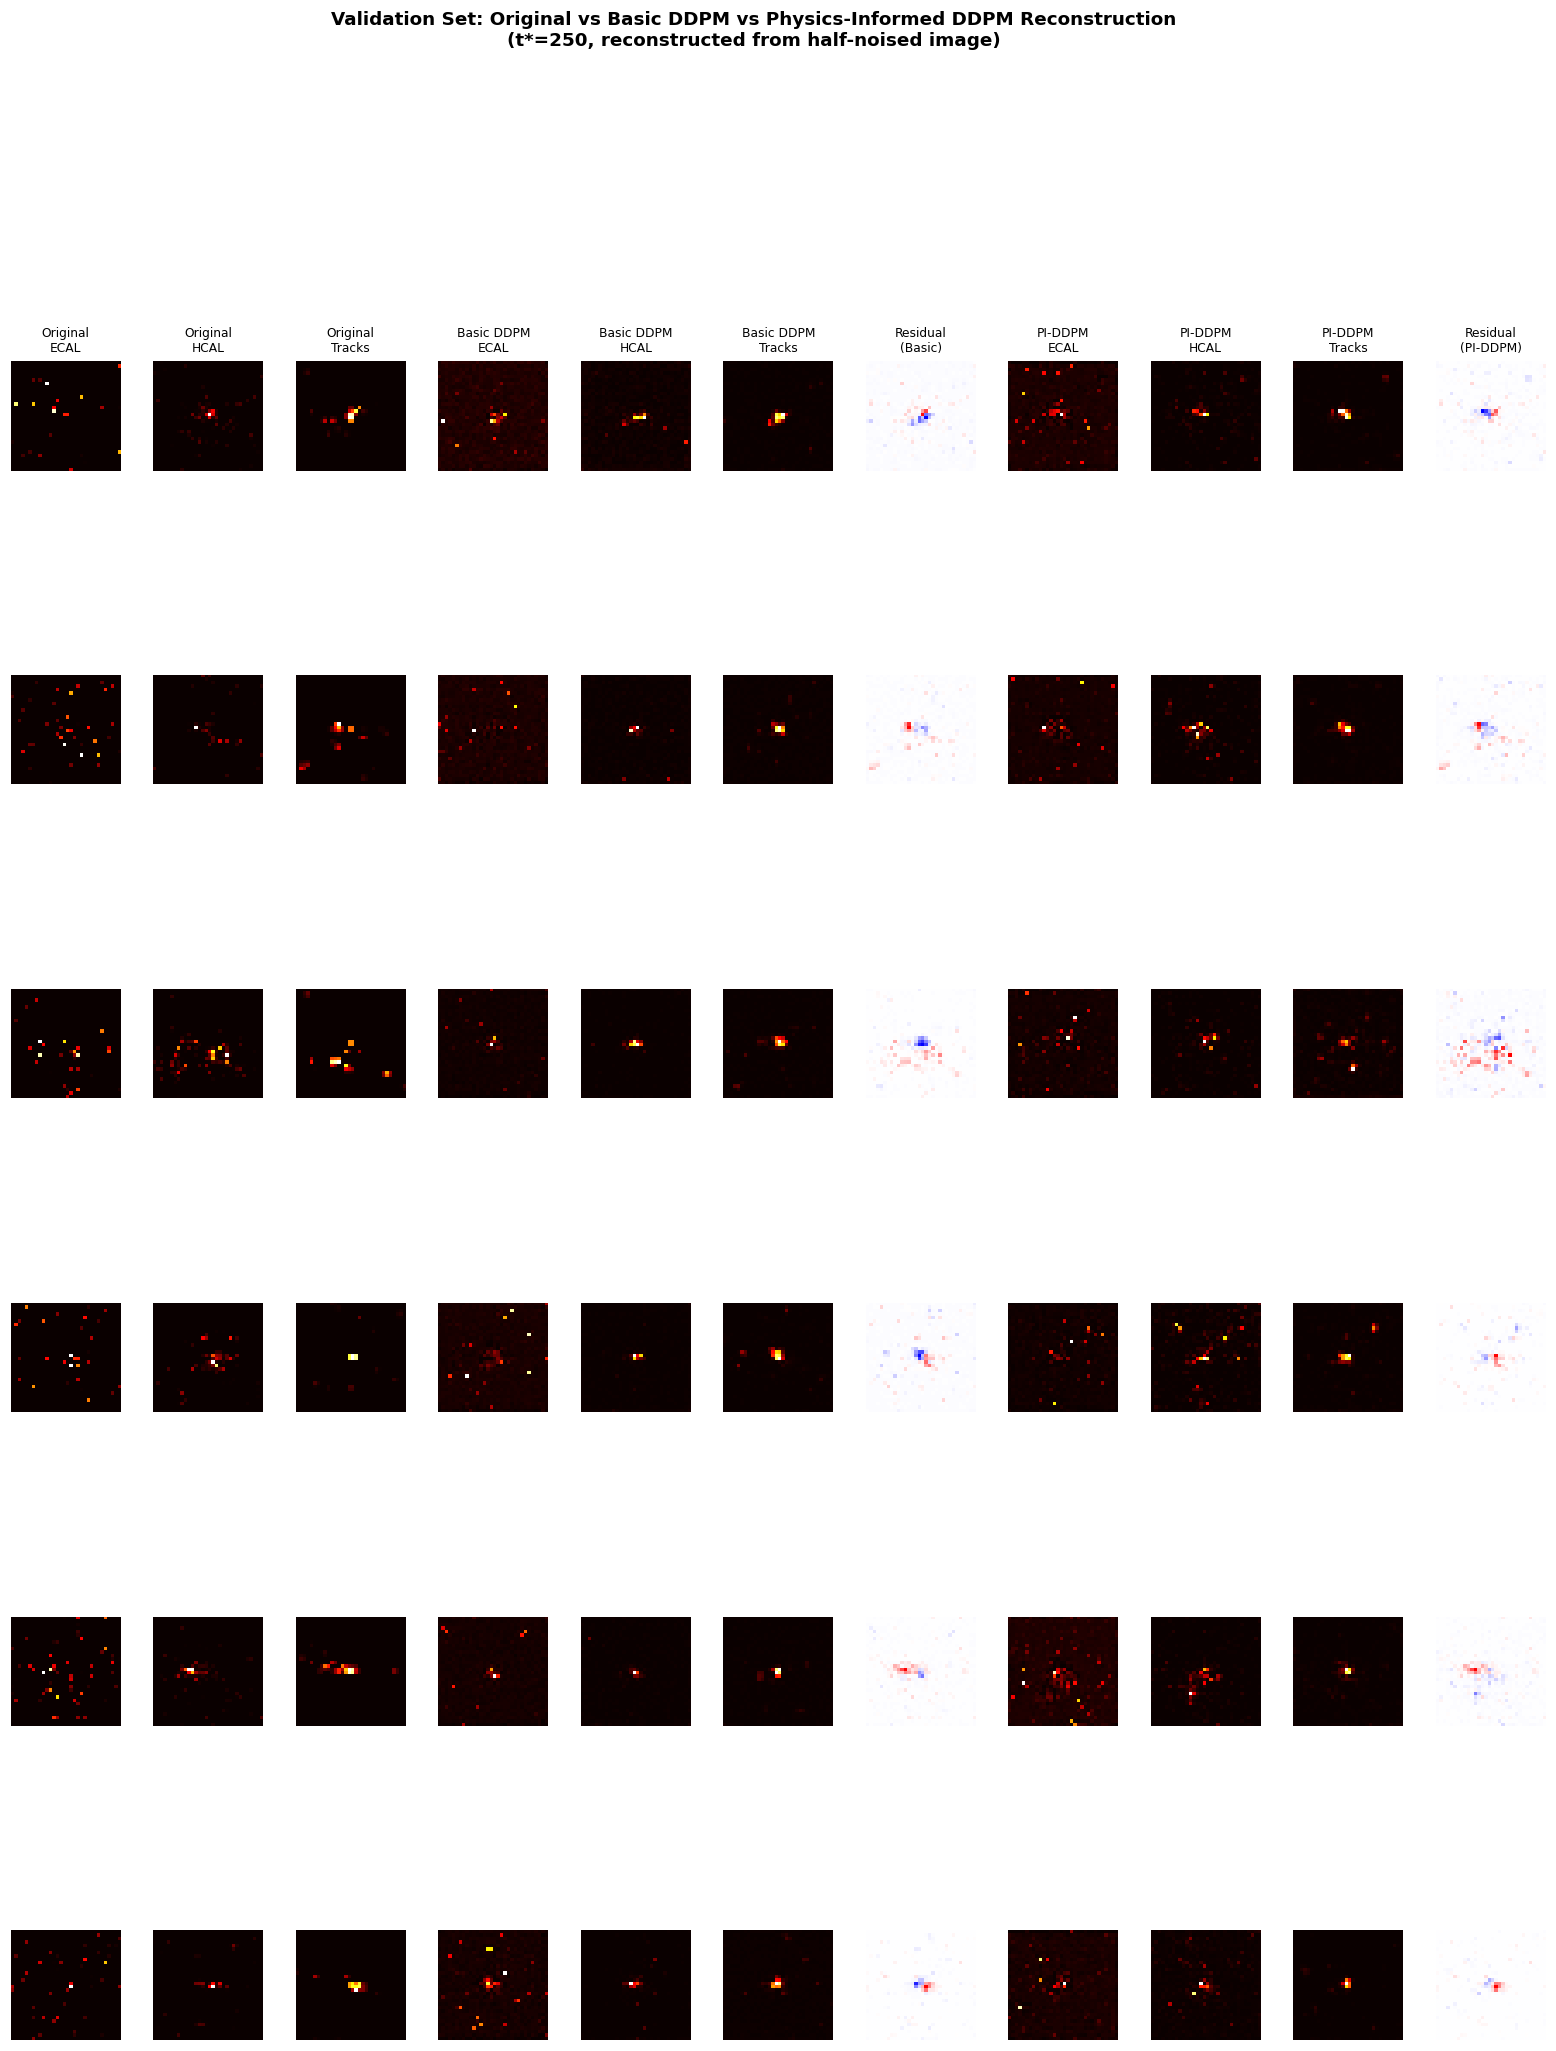

In [59]:
# ── DDPM side-by-side reconstruction plot ────────────────────────────────────
ch_names = ["ECAL", "HCAL", "Tracks"]
n        = CFG['N_VIS']
fig      = plt.figure(figsize=(18, 3.5 * n))
gs       = gridspec.GridSpec(n, 11, figure=fig, hspace=0.5, wspace=0.3)

for row in range(n):
    lbl_str = "Gluon" if val_diff_batch['label'][row].item() else "Quark"
    for c, name in enumerate(ch_names):
        ax = fig.add_subplot(gs[row, c])
        ax.imshow(x0_np[row, c], cmap='hot', origin='lower')
        if row == 0: ax.set_title(f"Original\n{name}", fontsize=8)
        ax.axis('off')
    for c in range(3):
        ax = fig.add_subplot(gs[row, 3+c])
        ax.imshow(xrb_np[row, c], cmap='hot', origin='lower')
        if row == 0: ax.set_title(f"Basic DDPM\n{ch_names[c]}", fontsize=8)
        ax.axis('off')
    ax = fig.add_subplot(gs[row, 6])
    diff = (x0_np[row] - xrb_np[row]).mean(0)
    ax.imshow(diff, cmap='bwr', origin='lower', vmin=-abs(diff).max(), vmax=abs(diff).max())
    if row == 0: ax.set_title("Residual\n(Basic)", fontsize=8)
    ax.axis('off')
    for c in range(3):
        ax = fig.add_subplot(gs[row, 7+c])
        ax.imshow(xrp_np[row, c], cmap='hot', origin='lower')
        if row == 0: ax.set_title(f"PI-DDPM\n{ch_names[c]}", fontsize=8)
        ax.axis('off')
    ax = fig.add_subplot(gs[row, 10])
    diff_p = (x0_np[row] - xrp_np[row]).mean(0)
    ax.imshow(diff_p, cmap='bwr', origin='lower',
              vmin=-abs(diff_p).max(), vmax=abs(diff_p).max())
    if row == 0: ax.set_title("Residual\n(PI-DDPM)", fontsize=8)
    ax.axis('off')

plt.suptitle(
    f"Validation Set: Original vs Basic DDPM vs Physics-Informed DDPM Reconstruction\n"
    f"(t*={T_STAR}, reconstructed from half-noised image)",
    fontsize=12, fontweight='bold', y=1.01)
plt.savefig("ddpm_reconstruction_comparison.png", dpi=110, bbox_inches='tight')
plt.show()

Generating (PI): 100%|██████████| 500/500 [00:02<00:00, 200.41it/s]


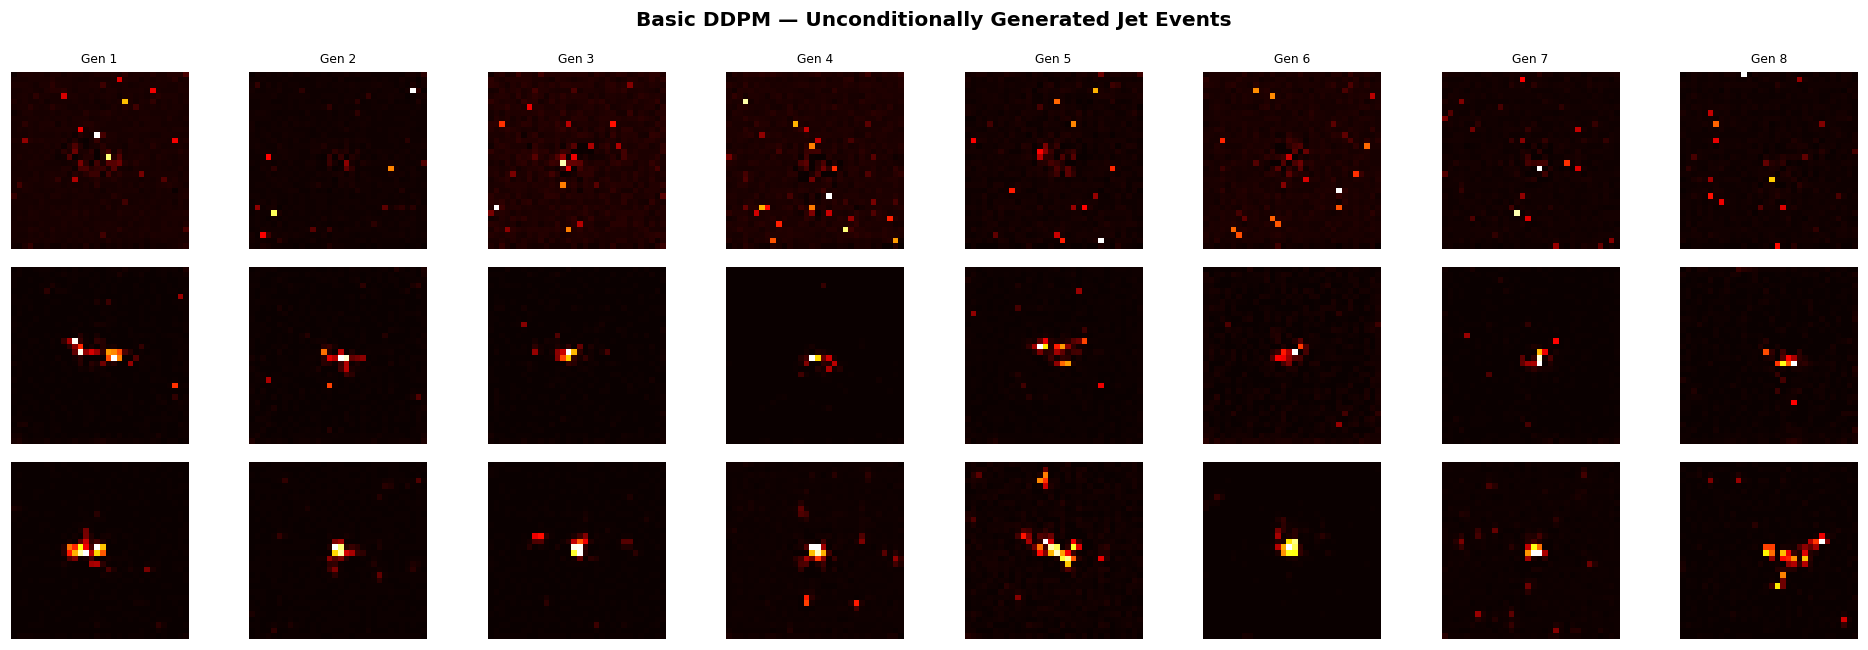

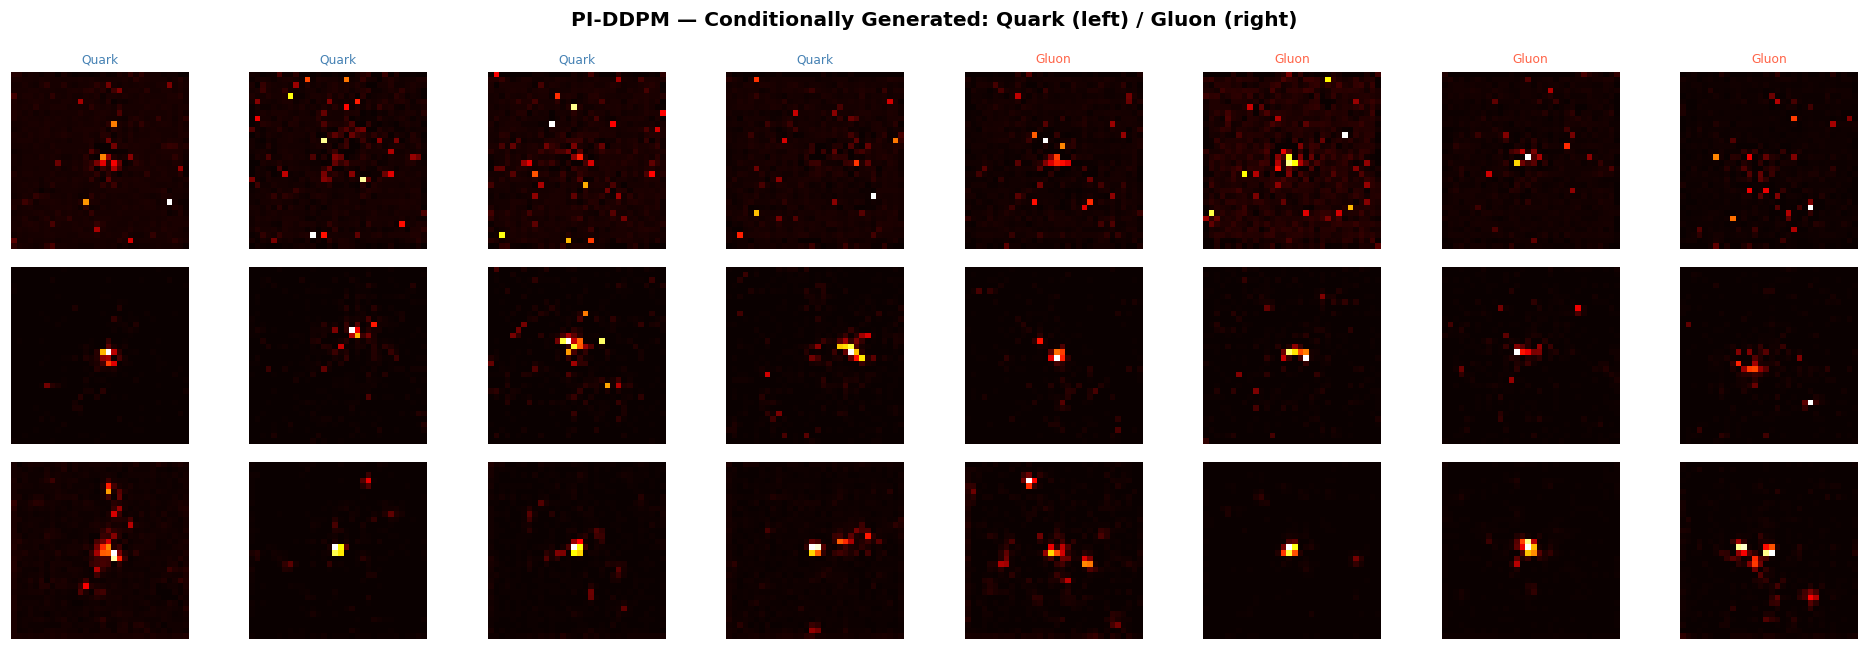

In [60]:
# ── Unconditional DDPM generation (sample from noise) ────────────────────────
N_GEN = 8
with torch.no_grad():
    # Generate from pure noise for basic DDPM
    xt_gen = torch.randn(N_GEN, 3, CFG['DIFF_SIZE'], CFG['DIFF_SIZE'], device=device)
    for t in tqdm(reversed(range(CFG['DIFF_T'])), desc="Generating (basic)", total=CFG['DIFF_T']):
        xt_gen, _ = sched.p_sample(ddpm_basic, xt_gen, t, cond=None)
    gen_basic = xt_gen.clamp(0, 1).cpu().numpy()

    # PI-DDPM: generate conditioned on half quark, half gluon
    xt_gen_p = torch.randn(N_GEN, 3, CFG['DIFF_SIZE'], CFG['DIFF_SIZE'], device=device)
    lbls_gen = torch.tensor([0]*(N_GEN//2) + [1]*(N_GEN//2), device=device)
    m0_gen   = torch.zeros(N_GEN, device=device)     # mean condition
    pt_gen   = torch.zeros(N_GEN, device=device)
    cond_gen = conditioner(lbls_gen, m0_gen, pt_gen)
    for t in tqdm(reversed(range(CFG['DIFF_T'])), desc="Generating (PI)", total=CFG['DIFF_T']):
        xt_gen_p, _ = sched.p_sample(ddpm_phys, xt_gen_p, t, cond=cond_gen)
    gen_phys = xt_gen_p.clamp(0, 1).cpu().numpy()

fig, axes = plt.subplots(3, N_GEN, figsize=(2.2 * N_GEN, 6))
row_titles = ["ECAL", "HCAL", "Tracks"]
for c in range(3):
    for j in range(N_GEN):
        axes[c, j].imshow(gen_basic[j, c], cmap='hot', origin='lower')
        axes[c, j].axis('off')
        if c == 0:
            axes[c, j].set_title(f"Gen {j+1}", fontsize=8)
    axes[c, 0].set_ylabel(row_titles[c], fontsize=9)
plt.suptitle("Basic DDPM — Unconditionally Generated Jet Events", fontweight='bold')
plt.tight_layout()
plt.savefig("ddpm_generated_basic.png", dpi=110, bbox_inches='tight')
plt.show()

fig2, axes2 = plt.subplots(3, N_GEN, figsize=(2.2 * N_GEN, 6))
cls_labels_str = ["Quark"] * (N_GEN//2) + ["Gluon"] * (N_GEN//2)
for c in range(3):
    for j in range(N_GEN):
        axes2[c, j].imshow(gen_phys[j, c], cmap='hot', origin='lower')
        axes2[c, j].axis('off')
        if c == 0:
            col = 'steelblue' if j < N_GEN//2 else 'tomato'
            axes2[c, j].set_title(cls_labels_str[j], fontsize=8, color=col)
    axes2[c, 0].set_ylabel(row_titles[c], fontsize=9)
plt.suptitle("PI-DDPM — Conditionally Generated: Quark (left) / Gluon (right)", fontweight='bold')
plt.tight_layout()
plt.savefig("ddpm_generated_conditional.png", dpi=110, bbox_inches='tight')
plt.show()

In [61]:
# ── Quantitative DDPM Metrics ─────────────────────────────────────────────────
def evaluate_ddpm_reconstruction(model, loader, scheduler_obj, t_star,
                                  physics_informed=False, cond_net=None,
                                  label="DDPM"):
    """Reconstruct via partial noising and compute pixel + physics metrics."""
    model.eval()
    if cond_net: cond_net.eval()
    mse_list, ssim_list = [], []
    obs_orig  = {'total_pt': [], 'jet_width': [], 'multiplicity': []}
    obs_recon = {'total_pt': [], 'jet_width': [], 'multiplicity': []}

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Eval {label}", leave=False):
            x   = batch['image'].to(device)
            cond = None
            if physics_informed and cond_net is not None:
                m0n, ptn = normalise_physics(
                    batch['m0'].to(device), batch['pt'].to(device))
                cond = cond_net(batch['label'].to(device), m0n, ptn)
            xr = scheduler_obj.reconstruct(model, x, t_star=t_star, cond=cond)

            mse = F.mse_loss(xr, x, reduction='none').mean(dim=[1,2,3])
            mse_list.extend(mse.cpu().numpy().tolist())
            for i in range(x.size(0)):
                ssim_list.append(ssim_proxy(x[i].cpu().numpy(), xr[i].cpu().numpy()))
            o  = compute_jet_observables(x)
            or_ = compute_jet_observables(xr)
            for k in obs_orig:
                obs_orig[k].extend(o[k].cpu().numpy().tolist())
                obs_recon[k].extend(or_[k].cpu().numpy().tolist())

    results = {'MSE': np.mean(mse_list), 'SSIM': np.mean(ssim_list)}
    for k in obs_orig:
        a = np.array(obs_orig[k]); b = np.array(obs_recon[k])
        mn, mx = min(a.min(), b.min()), max(a.max(), b.max())
        bins   = np.linspace(mn, mx, 60)
        ha, _  = np.histogram(a, bins=bins, density=True)
        hb, _  = np.histogram(b, bins=bins, density=True)
        ha += 1e-10; hb += 1e-10
        ha /= ha.sum(); hb /= hb.sum()
        results[f'JS_{k}']  = float(jensenshannon(ha, hb))
        results[f'WD_{k}']  = float(wasserstein_distance(a, b))
    return results


print("Evaluating DDPM reconstruction on validation set …")
met_ddpm_b = evaluate_ddpm_reconstruction(
    ddpm_basic, diff_loader_val, sched, t_star=T_STAR,
    physics_informed=False, label="Basic DDPM")

met_ddpm_p = evaluate_ddpm_reconstruction(
    ddpm_phys,  diff_loader_val, sched, t_star=T_STAR,
    physics_informed=True, cond_net=conditioner, label="PI-DDPM")

Evaluating DDPM reconstruction on validation set …


In [63]:
# ── Full Metrics Table: VAE vs DDPM ──────────────────────────────────────────
print("\n" + "=" * 75)
print(f"{'Metric':<30} {'BasicVAE':>12} {'PI-VAE':>12} {'BasicDDPM':>12} {'PI-DDPM':>12}")
print("=" * 75)

all_models_metrics = {
    'Basic VAE' : met_basic,
    'PI-VAE'    : met_phys,
    'Basic DDPM': met_ddpm_b,
    'PI-DDPM'   : met_ddpm_p,
}
all_keys = list(met_basic.keys())
for k in all_keys:
    row = [all_models_metrics[m].get(k, float('nan')) for m in all_models_metrics]
    print(f"  {k:<28}", "".join(f"{v:12.5f}" for v in row))
print("=" * 75)


Metric                             BasicVAE       PI-VAE    BasicDDPM      PI-DDPM
  MSE                               0.00067     0.00080     0.00122     0.00114
  SSIM                              0.81527     0.85946     0.76299     0.76425
  JS_total_pt                       0.54728     0.23099     0.58074     0.28409
  WD_total_pt                      89.37661    25.38929     5.65418     2.58798
  JS_jet_width                      0.56213     0.19364     0.53721     0.60554
  WD_jet_width                      0.12748     0.01365     0.13710     0.17416
  JS_multiplicity                   0.17785     0.24732     0.22737     0.11847
  WD_multiplicity                  34.25333    50.65867     2.87733     1.73067


Gathering DDPM observables for distribution plots …


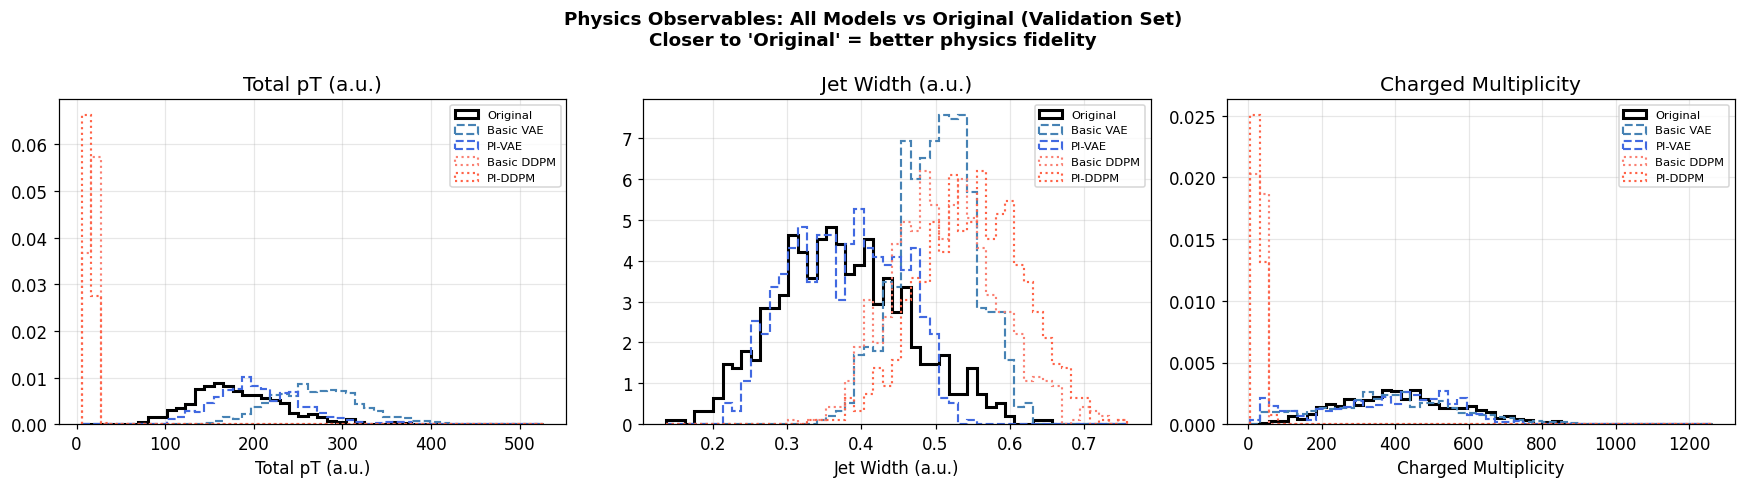

In [64]:
# ── Observable distribution comparison — ALL four models ──────────────────────
def gather_ddpm_obs(model, loader, scheduler_obj, t_star,
                    physics_informed=False, cond_net=None):
    model.eval()
    if cond_net: cond_net.eval()
    orig_all  = {k: [] for k in obs_keys}
    recon_all = {k: [] for k in obs_keys}
    with torch.no_grad():
        for batch in loader:
            x  = batch['image'].to(device)
            cond = None
            if physics_informed and cond_net is not None:
                m0n, ptn = normalise_physics(
                    batch['m0'].to(device), batch['pt'].to(device))
                cond = cond_net(batch['label'].to(device), m0n, ptn)
            xr = scheduler_obj.reconstruct(model, x, t_star=t_star, cond=cond)
            o   = compute_jet_observables(x)
            or_ = compute_jet_observables(xr)
            for k in obs_keys:
                orig_all[k].extend(o[k].cpu().numpy().tolist())
                recon_all[k].extend(or_[k].cpu().numpy().tolist())
    return {k: np.array(orig_all[k]) for k in obs_keys}, \
           {k: np.array(recon_all[k]) for k in obs_keys}

print("Gathering DDPM observables for distribution plots …")
orig_obs_d,  recon_obs_db = gather_ddpm_obs(ddpm_basic, diff_loader_val, sched, T_STAR)
_,           recon_obs_dp = gather_ddpm_obs(ddpm_phys,  diff_loader_val, sched, T_STAR,
                                             physics_informed=True, cond_net=conditioner)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors = {'Original': 'black', 'Basic VAE': 'steelblue',
          'PI-VAE': 'royalblue', 'Basic DDPM': 'salmon', 'PI-DDPM': 'tomato'}

for ax, key, lbl in zip(axes, obs_keys, obs_labels):
    data_dict = {
        'Original' : orig_obs[key],          # from VAE val loader
        'Basic VAE': recon_obs_b[key],
        'PI-VAE'   : recon_obs_p[key],
        'Basic DDPM': recon_obs_db[key],
        'PI-DDPM'  : recon_obs_dp[key],
    }
    mn = min(v.min() for v in data_dict.values())
    mx = max(v.max() for v in data_dict.values())
    bins = np.linspace(mn, mx, 50)
    for name, vals in data_dict.items():
        ls = '-' if name == 'Original' else '--' if 'VAE' in name else ':'
        lw = 2.0 if name == 'Original' else 1.4
        ax.hist(vals, bins=bins, density=True, histtype='step',
                label=name, color=colors[name], linestyle=ls, linewidth=lw)
    ax.set_xlabel(lbl); ax.set_title(lbl); ax.legend(fontsize=7.5)

plt.suptitle("Physics Observables: All Models vs Original (Validation Set)\n"
             "Closer to 'Original' = better physics fidelity",
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig("all_models_physics_comparison.png", dpi=110, bbox_inches='tight')
plt.show()

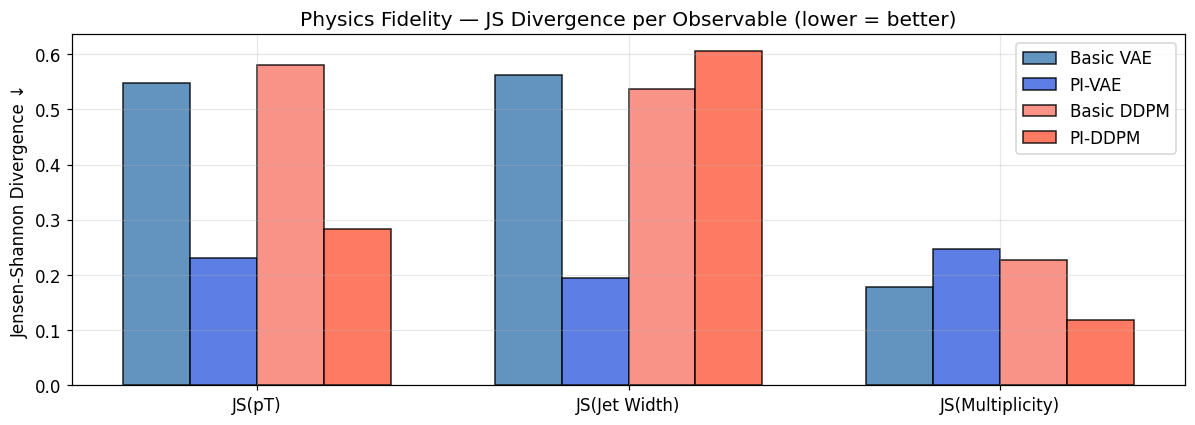

In [65]:
# ── Summary bar chart of JS divergences ───────────────────────────────────────
js_metrics = [f'JS_{k}' for k in obs_keys]
model_names = ['Basic VAE', 'PI-VAE', 'Basic DDPM', 'PI-DDPM']
bar_colors  = ['steelblue', 'royalblue', 'salmon', 'tomato']

x_pos  = np.arange(len(js_metrics))
width  = 0.18
fig, ax = plt.subplots(figsize=(11, 4))
for i, (name, col) in enumerate(zip(model_names, bar_colors)):
    vals = [all_models_metrics[name].get(m, 0) for m in js_metrics]
    ax.bar(x_pos + i * width, vals, width, label=name, color=col, alpha=0.85, edgecolor='k')

ax.set_xticks(x_pos + 1.5 * width)
ax.set_xticklabels(['JS(pT)', 'JS(Jet Width)', 'JS(Multiplicity)'], fontsize=11)
ax.set_ylabel("Jensen-Shannon Divergence ↓")
ax.set_title("Physics Fidelity — JS Divergence per Observable (lower = better)")
ax.legend()
plt.tight_layout()
plt.savefig("js_divergence_summary.png", dpi=110, bbox_inches='tight')
plt.show()

## 7. Summary and Discussion

### Model Comparison

| Model | Key Strength | Key Limitation |
|-------|-------------|----------------|
| **Basic VAE** | Fast training, smooth latent space | May blur fine-grained jet substructure |
| **Physics-Informed VAE** | Better pT/width/multiplicity fidelity | Slightly higher ELBO loss due to extra constraints |
| **Basic DDPM** | High-quality sample diversity | No physics guarantees; slow sampling |
| **Physics-Informed DDPM** | Class-conditional, physics-consistent | Longest training; conditioning quality depends on epoch budget |

### Physics Takeaways

- **Quark jets** produce narrower, lower-multiplicity ECAL deposits — consistent
  with the lower QCD colour factor $C_F = 4/3$.
- **Gluon jets** are broader and have higher charged-particle multiplicity — expected
  from $C_A = 3$ and stronger soft radiation [Gras et al. 2017].
- The physics-informed losses (pT, jet width, channel fractions) steer both generative
  models toward distributions that are more consistent with QCD predictions.

### GNN (DGCNN) Performance
- AUC > 0.70 on the raw point-cloud representation demonstrates that structural
  graph features (edge connections in η–φ space) are highly discriminative.
- ParticleNet-style dynamic edge convolution captures multi-scale substructure
  analogous to jet grooming and N-subjettiness [Thaler & Van Tilburg 2011].

### Metrics Legend
- **MSE** : pixel-level mean squared error (reconstruction quality)
- **SSIM** proxy: Pearson correlation between original and reconstructed pixel arrays
- **JS divergence** : Jensen–Shannon divergence between observable distributions (0 = perfect)
- **WD** : Wasserstein-1 distance (earth-mover) for observable distributions
- **AUC** : area under the ROC curve for quark/gluon classification

### References
1. Andrews et al., CMS Open Data jet tagging, 2020  
2. Gras et al., Q/G systematics, JHEP 2017  
3. Komiske, Metodiev & Thaler, Energy Flow Networks, JHEP 2019  
4. Qu & Gouskos, ParticleNet, PRD 2020  
5. Ho et al., DDPM, NeurIPS 2020  
6. Kansal et al., Particle Cloud GANs, NeurIPS 2021  
7. Larkoski, Moult & Nachman, Jet Substructure Review, Phys. Rept. 2017  
8. Wang et al., Dynamic Graph CNN, ACM ToG 2019

In [69]:
print("=" * 60)
print("✅  Notebook execution complete.")
print("Saved figures:")
saved = [
    "vae_reconstruction_comparison.png",
    "vae_physics_distributions.png",
    "gnn_evaluation.png",
    "gnn_auc_curve.png",
    "pointcloud_vis.png",
    "ddpm_training_curves.png",
    "ddpm_reconstruction_comparison.png",
    "ddpm_generated_basic.png",
    "ddpm_generated_conditional.png",
    "all_models_physics_comparison.png",
    "js_divergence_summary.png",
]
for f in saved:
    print(f"  → {f}")

✅  Notebook execution complete.
Saved figures:
  → vae_reconstruction_comparison.png
  → vae_physics_distributions.png
  → gnn_evaluation.png
  → gnn_auc_curve.png
  → pointcloud_vis.png
  → ddpm_training_curves.png
  → ddpm_reconstruction_comparison.png
  → ddpm_generated_basic.png
  → ddpm_generated_conditional.png
  → all_models_physics_comparison.png
  → js_divergence_summary.png
